# In this notebook, we will evalute our models predictions across the ACC Wrestling Conference Tournament

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# -- Read in data
acc_preds = pd.read_csv('all_predictions_master_ACC.csv')
display(acc_preds)
print(acc_preds.columns)

,wrestler1,wrestler2,home_wrestler,away_wrestler,logreg_pred,logreg_home_prob,logreg_away_prob,logreg_winner,logreg_winner_prob,dt_pred,...,xgb1_winner,xgb1_winner_prob,xgb2_pred,xgb2_home_prob,xgb2_away_prob,xgb2_winner,xgb2_winner_prob,weight_class,all_agree,avg_confidence
0,Eddie Ventresca,Kysen Terukina,Eddie Ventresca,Kysen Terukina,1,0.5813,0.4187,Eddie Ventresca,0.5813,1,...,Eddie Ventresca,0.6230,1,0.8076,0.1924,Eddie Ventresca,0.8076,125,True,0.655750
1,Eddie Ventresca,Tyler Chappell,Eddie Ventresca,Tyler Chappell,1,0.7456,0.2544,Eddie Ventresca,0.7456,1,...,Eddie Ventresca,0.8499,1,0.9109,0.0891,Eddie Ventresca,0.9109,125,True,0.813100
2,Eddie Ventresca,Vincent Robinson,Eddie Ventresca,Vincent Robinson,1,0.5276,0.4724,Eddie Ventresca,0.5276,1,...,Eddie Ventresca,0.6343,1,0.6695,0.3305,Eddie Ventresca,0.6695,125,True,0.610625
3,Eddie Ventresca,Keyveon Roller,Eddie Ventresca,Keyveon Roller,1,0.6148,0.3852,Eddie Ventresca,0.6148,1,...,Eddie Ventresca,0.6353,1,0.8324,0.1676,Eddie Ventresca,0.8324,125,True,0.707125
4,Eddie Ventresca,Spencer Von Savoye,Eddie Ventresca,Spencer Von Savoye,1,0.8109,0.1891,Eddie Ventresca,0.8109,1,...,Eddie Ventresca,0.9165,1,0.9725,0.0275,Eddie Ventresca,0.9725,125,True,0.897425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,Jim Mullen,Luke Duthie,Jim Mullen,Luke Duthie,1,0.7385,0.2615,Jim Mullen,0.7385,1,...,Jim Mullen,0.7728,1,0.8063,0.1937,Jim Mullen,0.8063,285,True,0.765900
206,Jim Mullen,Dayton Pitzer,Jim Mullen,Dayton Pitzer,0,0.4386,0.5614,Dayton Pitzer,0.5614,0,...,Dayton Pitzer,0.5559,1,0.5273,0.4727,Jim Mullen,0.5273,285,False,0.543900
207,Jacob Levy,Luke Duthie,Jacob Levy,Luke Duthie,1,0.6873,0.3127,Jacob Levy,0.6873,0,...,Luke Duthie,0.5048,0,0.3867,0.6133,Luke Duthie,0.6133,285,False,0.584100
208,Jacob Levy,Dayton Pitzer,Dayton Pitzer,Jacob Levy,1,0.6266,0.3734,Dayton Pitzer,0.6266,1,...,Dayton Pitzer,0.8103,1,0.9128,0.0872,Dayton Pitzer,0.9128,285,True,0.809875


Index(['wrestler1', 'wrestler2', 'home_wrestler', 'away_wrestler',
       'logreg_pred', 'logreg_home_prob', 'logreg_away_prob', 'logreg_winner',
       'logreg_winner_prob', 'dt_pred', 'dt_home_prob', 'dt_away_prob',
       'dt_winner', 'dt_winner_prob', 'xgb1_pred', 'xgb1_home_prob',
       'xgb1_away_prob', 'xgb1_winner', 'xgb1_winner_prob', 'xgb2_pred',
       'xgb2_home_prob', 'xgb2_away_prob', 'xgb2_winner', 'xgb2_winner_prob',
       'weight_class', 'all_agree', 'avg_confidence'],
      dtype='object')


## Test on one weight class

In [3]:
# ============================================
# FUNCTION TO EVALUATE A SINGLE WEIGHT CLASS
# ============================================

def evaluate_weight_class(weight_class, actual_results, special_matches, 
                         predictions_df, conference="ACC", save_plots=False):
    """
    Evaluate all models for a specific weight class.
    
    Parameters:
    - weight_class: int (e.g., 125, 133, etc.)
    - actual_results: dict with (w1, w2, match_round) -> winner 
      (match_round helps distinguish multiple meetings)
    - special_matches: list of tuples for matches ending in injury/forfeit/DQ
    - predictions_df: dataframe with all predictions
    - conference: string for plot titles
    - save_plots: boolean to save plots to file
    
    Returns:
    - eval_df: detailed evaluation dataframe
    - summary_dict: dictionary with summary statistics
    """
    
    print("\n" + "="*100)
    print(f"🏋️  EVALUATING {weight_class}lbs - {conference} CONFERENCE")
    print("="*100)
    
    # Filter predictions for this weight class
    weight_preds = predictions_df[predictions_df['weight_class'] == weight_class].copy()
    
    if len(weight_preds) == 0:
        print(f"⚠️ No predictions found for {weight_class}lbs")
        return None, None
    
    print(f"\n📊 {weight_class}lbs predictions in dataset: {len(weight_preds)} matchups")
    
    # Create lookup dictionary - note: predictions don't have multiple entries for same pair
    # So we'll need to handle multiple actual matches carefully
    pred_lookup = {}
    for _, row in weight_preds.iterrows():
        w1, w2 = row['wrestler1'], row['wrestler2']
        key = tuple(sorted([w1, w2]))
        # Store the prediction row - if multiple actual matches between same pair,
        # they'll all use the same prediction (since model only predicts once per pair)
        pred_lookup[key] = row
    
    # Evaluate predictions
    results = []
    
    # Track matches for summary
    match_counter = {}
    
    for (w1, w2, match_round), actual_winner in actual_results.items():
        key = tuple(sorted([w1, w2]))
        
        # Track this matchup for debugging
        matchup_key = f"{w1} vs {w2}"
        if matchup_key not in match_counter:
            match_counter[matchup_key] = 0
        match_counter[matchup_key] += 1
        match_number = match_counter[matchup_key]
        
        if key not in pred_lookup:
            print(f"⚠️ Warning: No prediction found for {w1} vs {w2} (Match {match_number}: {match_round})")
            continue
        
        row = pred_lookup[key]
        is_special = (w1, w2, match_round) in special_matches or (w2, w1, match_round) in special_matches
        result_type = 'SPECIAL' if is_special else 'REGULAR'
        
        # Create a unique match ID
        match_id = f"{w1}_vs_{w2}_{match_round.replace(' ', '_')}"
        
        results.append({
            'Match ID': match_id,
            'Round': match_round,
            'Wrestler 1': w1,
            'Wrestler 2': w2,
            'Match Number': f"{match_number} of {match_counter[matchup_key]}",
            'Actual Winner': actual_winner,
            'Result Type': result_type,
            
            # Logistic Regression
            'LR Predicted': row['logreg_winner'],
            'LR Correct': row['logreg_winner'] == actual_winner,
            'LR Conf': row['logreg_winner_prob'],
            
            # Decision Tree
            'DT Predicted': row['dt_winner'],
            'DT Correct': row['dt_winner'] == actual_winner,
            'DT Conf': row['dt_winner_prob'],
            
            # XGBoost (no ranks)
            'XGB1 Predicted': row['xgb1_winner'],
            'XGB1 Correct': row['xgb1_winner'] == actual_winner,
            'XGB1 Conf': row['xgb1_winner_prob'],
            
            # XGBoost (with ranks)
            'XGB2 Predicted': row['xgb2_winner'],
            'XGB2 Correct': row['xgb2_winner'] == actual_winner,
            'XGB2 Conf': row['xgb2_winner_prob'],
        })
    
    eval_df = pd.DataFrame(results)
    
    if len(eval_df) == 0:
        print(f"⚠️ No matches evaluated for {weight_class}lbs")
        return None, None
    
    # Display multiple match warning if applicable
    multiple_matches = [k for k, v in match_counter.items() if v > 1]
    if multiple_matches:
        print("\n" + "="*100)
        print("⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS")
        print("="*100)
        for matchup in multiple_matches:
            print(f"   {matchup}: {match_counter[matchup]} matches")
            # Show which rounds
            matchup_rounds = [r for (w1, w2, r) in actual_results.keys() 
                            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup]
            print(f"      Rounds: {', '.join(matchup_rounds)}")
    
    # Display detailed evaluation
    print("\n" + "="*100)
    print(f"📊 DETAILED EVALUATION - {weight_class}lbs ALL MATCHES")
    print("="*100)
    
    # Format for display
    display_df = eval_df.copy()
    for col in ['LR Conf', 'DT Conf', 'XGB1 Conf', 'XGB2 Conf']:
        display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'
    
    # Add emoji columns for display
    display_df['LR Correct'] = display_df['LR Correct'].map({True: '✅', False: '❌'})
    display_df['DT Correct'] = display_df['DT Correct'].map({True: '✅', False: '❌'})
    display_df['XGB1 Correct'] = display_df['XGB1 Correct'].map({True: '✅', False: '❌'})
    display_df['XGB2 Correct'] = display_df['XGB2 Correct'].map({True: '✅', False: '❌'})
    
    # Show relevant columns
    show_cols = ['Round', 'Wrestler 1', 'Wrestler 2', 'Match Number', 'Actual Winner',
                 'LR Correct', 'LR Conf', 'DT Correct', 'DT Conf', 
                 'XGB1 Correct', 'XGB1 Conf', 'XGB2 Correct', 'XGB2 Conf']
    display(display_df[show_cols])
    
    # Calculate metrics
    def calculate_metrics(df, include_special=True):
        if not include_special:
            df = df[df['Result Type'] == 'REGULAR'].copy()
        
        if len(df) == 0:
            return {}
        
        metrics = {}
        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]
        
        for col, name in models:
            correct_count = df[col].sum()  # Now boolean
            total = len(df)
            accuracy = (correct_count / total * 100) if total > 0 else 0
            metrics[name] = {
                'correct': int(correct_count),
                'total': total,
                'accuracy': accuracy
            }
        
        return metrics
    
    all_metrics = calculate_metrics(eval_df, include_special=True)
    regular_metrics = calculate_metrics(eval_df, include_special=False)
    
    # Display metrics
    print("\n" + "="*100)
    print(f"📊 MODEL ACCURACY METRICS - {weight_class}lbs")
    print("="*100)
    
    print("\n🔴 INCLUDING ALL MATCHES (Special Results Included):")
    if all_metrics:
        metrics_df_all = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}", 
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in all_metrics.items()
        ])
        display(metrics_df_all)
    else:
        print("   No matches to evaluate")
    
    print("\n🟢 REGULAR MATCHES ONLY (Excluding Special Results):")
    if regular_metrics:
        metrics_df_regular = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}", 
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in regular_metrics.items()
        ])
        display(metrics_df_regular)
    else:
        print("   No regular matches to evaluate")
    
    # ============================================
    # BAR PLOTS
    # ============================================
    if len(eval_df) > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        all_df = eval_df.copy()
        regular_df = eval_df[eval_df['Result Type'] == 'REGULAR'].copy()
        
        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]
        
        model_colors = {'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}
        
        # Top row: ALL matches
        for idx, (col, name) in enumerate(models):
            correct_counts = all_df[col].sum()
            incorrect_counts = len(all_df) - correct_counts
            
            bars = axes[0, idx].bar(['Correct', 'Incorrect'], 
                                    [correct_counts, incorrect_counts],
                                    color=[model_colors['Correct'], model_colors['Incorrect']],
                                    edgecolor='black', linewidth=1)
            
            # Add count labels on bars
            for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                height = bar.get_height()
                axes[0, idx].text(bar.get_x() + bar.get_width()/2., height,
                                 f'{int(count)}', ha='center', va='bottom', fontweight='bold')
            
            accuracy = correct_counts / len(all_df) * 100
            axes[0, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
            axes[0, idx].set_ylabel('Number of Matches')
            axes[0, idx].set_ylim(0, len(all_df) + 1)
            axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Bottom row: REGULAR matches only
        if len(regular_df) > 0:
            for idx, (col, name) in enumerate(models):
                correct_counts = regular_df[col].sum()
                incorrect_counts = len(regular_df) - correct_counts
                
                bars = axes[1, idx].bar(['Correct', 'Incorrect'], 
                                        [correct_counts, incorrect_counts],
                                        color=[model_colors['Correct'], model_colors['Incorrect']],
                                        edgecolor='black', linewidth=1)
                
                # Add count labels on bars
                for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                    height = bar.get_height()
                    axes[1, idx].text(bar.get_x() + bar.get_width()/2., height,
                                     f'{int(count)}', ha='center', va='bottom', fontweight='bold')
                
                accuracy = correct_counts / len(regular_df) * 100
                axes[1, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
                axes[1, idx].set_ylabel('Number of Matches')
                axes[1, idx].set_ylim(0, len(regular_df) + 1)
                axes[1, idx].grid(axis='y', alpha=0.3)
        else:
            for idx in range(4):
                axes[1, idx].text(0.5, 0.5, 'No Regular Matches', ha='center', va='center', 
                                 fontsize=14, transform=axes[1, idx].transAxes)
                axes[1, idx].set_title('No Data')
                axes[1, idx].set_xticks([])
                axes[1, idx].set_yticks([])
        
        # Add row labels
        axes[0, 0].annotate('ALL MATCHES\n(Special Results Included)', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')
        axes[1, 0].annotate('REGULAR MATCHES ONLY\n(Excluding Special)', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')
        
        # Add note about multiple matches if applicable
        if multiple_matches:
            fig.text(0.5, 0.02, f'⚠️ Note: {len(multiple_matches)} matchup(s) had multiple meetings',
                    ha='center', fontsize=10, style='italic', color='red')
        
        plt.suptitle(f'{weight_class}lbs - {conference} Conference Model Performance', fontsize=16, y=1.02)
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f'{conference}_{weight_class}lbs_performance_bars.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # Model Rankings
    print("\n" + "="*100)
    print(f"📊 MODEL RANKING - {weight_class}lbs")
    print("="*100)
    
    if all_metrics:
        ranking_df_all = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%", 
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(all_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])
        
        print("\n🏆 Model Ranking (All Matches - Special Results Included):")
        display(ranking_df_all)
    else:
        ranking_df_all = pd.DataFrame()
        print("\n🏆 No matches to rank")
    
    if regular_metrics:
        ranking_df_regular = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%", 
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(regular_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])
        
        print("\n🏆 Model Ranking (Regular Matches Only - Excluding Special Results):")
        display(ranking_df_regular)
    else:
        ranking_df_regular = pd.DataFrame()
        print("\n🏆 No regular matches to rank")
    
    # Summary Statistics
    print("\n" + "="*100)
    print(f"📊 SUMMARY STATISTICS - {weight_class}lbs")
    print("="*100)
    
    total_matches = len(eval_df)
    special_matches_count = (eval_df['Result Type'] == 'SPECIAL').sum()
    regular_matches_count = total_matches - special_matches_count
    unique_matchups = len(eval_df[['Wrestler 1', 'Wrestler 2']].drop_duplicates())
    
    summary_stats = pd.DataFrame([
        {'Metric': 'Conference', 'Value': conference},
        {'Metric': 'Weight Class', 'Value': f'{weight_class}lbs'},
        {'Metric': 'Total Matches Evaluated', 'Value': total_matches},
        {'Metric': 'Unique Matchups', 'Value': unique_matchups},
        {'Metric': 'Matchups with Multiple Meetings', 'Value': len(multiple_matches)},
        {'Metric': 'Matches with Special Results', 'Value': f"{special_matches_count} ({special_matches_count/total_matches*100:.1f}%)"},
        {'Metric': 'Regular Matches', 'Value': f"{regular_matches_count} ({regular_matches_count/total_matches*100:.1f}%)"},
    ])
    
    if not ranking_df_all.empty:
        summary_stats.loc[len(summary_stats)] = ['Best Model (All Matches)', ranking_df_all.iloc[0]['Model']]
        summary_stats.loc[len(summary_stats)] = ['Best Model Accuracy (All Matches)', ranking_df_all.iloc[0]['Accuracy']]
    
    if not ranking_df_regular.empty:
        summary_stats.loc[len(summary_stats)] = ['Best Model (Regular Only)', ranking_df_regular.iloc[0]['Model']]
        summary_stats.loc[len(summary_stats)] = ['Best Model Accuracy (Regular Only)', ranking_df_regular.iloc[0]['Accuracy']]
    
    display(summary_stats)
    
    # Complete Performance Summary
    print("\n" + "="*100)
    print(f"📊 COMPLETE MODEL PERFORMANCE SUMMARY - {weight_class}lbs")
    print("="*100)
    
    summary_complete = []
    for model in ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']:
        row = {
            'Model': model,
            'All Matches Accuracy': f"{all_metrics[model]['accuracy']:.1f}%" if model in all_metrics else 'N/A',
            'All Matches Correct': f"{all_metrics[model]['correct']}/{all_metrics[model]['total']}" if model in all_metrics else 'N/A',
        }
        
        if regular_metrics and model in regular_metrics:
            row['Regular Only Accuracy'] = f"{regular_metrics[model]['accuracy']:.1f}%"
            row['Regular Only Correct'] = f"{regular_metrics[model]['correct']}/{regular_metrics[model]['total']}"
        else:
            row['Regular Only Accuracy'] = 'N/A'
            row['Regular Only Correct'] = 'N/A'
        
        summary_complete.append(row)
    
    summary_complete_df = pd.DataFrame(summary_complete)
    display(summary_complete_df)
    
    # Create summary dictionary for later aggregation
    summary_dict = {
        'weight_class': weight_class,
        'total_matches': total_matches,
        'unique_matchups': unique_matchups,
        'multiple_meeting_matchups': len(multiple_matches),
        'special_matches': special_matches_count,
        'regular_matches': regular_matches_count,
        'all_metrics': all_metrics,
        'regular_metrics': regular_metrics,
        'ranking_all': ranking_df_all.iloc[0]['Model'] if not ranking_df_all.empty else None,
        'ranking_regular': ranking_df_regular.iloc[0]['Model'] if not ranking_df_regular.empty else None,
    }
    
    return eval_df, summary_dict






📋 SETTING UP 125lbs ACC TOURNAMENT RESULTS

📊 125lbs Results Summary:
   Total matches: 11
   Special matches: 1


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Kysen Terukina,Tyler Chappell,Kysen Terukina,REGULAR
1,Quarterfinal,Keyveon Roller,Vincent Robinson,Vincent Robinson,REGULAR
2,Quarterfinal,Spencer Von Savoye,Nico Provo,Nico Provo,REGULAR
3,Consolation Round 1,Keyveon Roller,Spencer Von Savoye,Keyveon Roller,REGULAR
4,Semifinal,Eddie Ventresca,Kysen Terukina,Eddie Ventresca,REGULAR
5,Semifinal,Nico Provo,Vincent Robinson,Nico Provo,REGULAR
6,Consolation Semi,Tyler Chappell,Vincent Robinson,Vincent Robinson,REGULAR
7,Consolation Semi,Keyveon Roller,Kysen Terukina,Kysen Terukina,REGULAR
8,3rd Place Match,Kysen Terukina,Vincent Robinson,Vincent Robinson,REGULAR
9,5th Place Match,Keyveon Roller,Tyler Chappell,Tyler Chappell,SPECIAL



✅ No multiple meetings detected

🔍 EVALUATING 125lbs

🏋️  EVALUATING 125lbs - ACC CONFERENCE

📊 125lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 125lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Kysen Terukina,Tyler Chappell,1 of 1,Kysen Terukina,✅,68.1%,✅,74.6%,✅,72.5%,✅,60.7%
1,Quarterfinal,Keyveon Roller,Vincent Robinson,1 of 1,Vincent Robinson,✅,59.1%,✅,61.1%,✅,68.1%,✅,76.1%
2,Quarterfinal,Spencer Von Savoye,Nico Provo,1 of 1,Nico Provo,✅,74.4%,✅,89.0%,✅,84.6%,✅,94.1%
3,Consolation Round 1,Keyveon Roller,Spencer Von Savoye,1 of 1,Keyveon Roller,✅,73.1%,✅,89.0%,✅,89.1%,✅,97.2%
4,Semifinal,Eddie Ventresca,Kysen Terukina,1 of 1,Eddie Ventresca,✅,58.1%,✅,61.1%,✅,62.3%,✅,80.8%
5,Semifinal,Nico Provo,Vincent Robinson,1 of 1,Nico Provo,❌,57.4%,❌,61.1%,❌,70.2%,❌,71.4%
6,Consolation Semi,Tyler Chappell,Vincent Robinson,1 of 1,Vincent Robinson,✅,72.6%,✅,74.6%,✅,84.3%,✅,81.3%
7,Consolation Semi,Keyveon Roller,Kysen Terukina,1 of 1,Kysen Terukina,✅,53.7%,❌,53.1%,✅,53.1%,✅,66.9%
8,3rd Place Match,Kysen Terukina,Vincent Robinson,1 of 1,Vincent Robinson,✅,55.7%,✅,61.1%,✅,68.2%,✅,80.5%
9,5th Place Match,Keyveon Roller,Tyler Chappell,1 of 1,Tyler Chappell,❌,65.0%,❌,74.6%,❌,74.8%,❌,61.0%



📊 MODEL ACCURACY METRICS - 125lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,9/11,81.8%
1,Decision Tree,8/11,72.7%
2,XGBoost (no ranks),9/11,81.8%
3,XGBoost (with ranks),9/11,81.8%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,9/10,90.0%
1,Decision Tree,8/10,80.0%
2,XGBoost (no ranks),9/10,90.0%
3,XGBoost (with ranks),9/10,90.0%


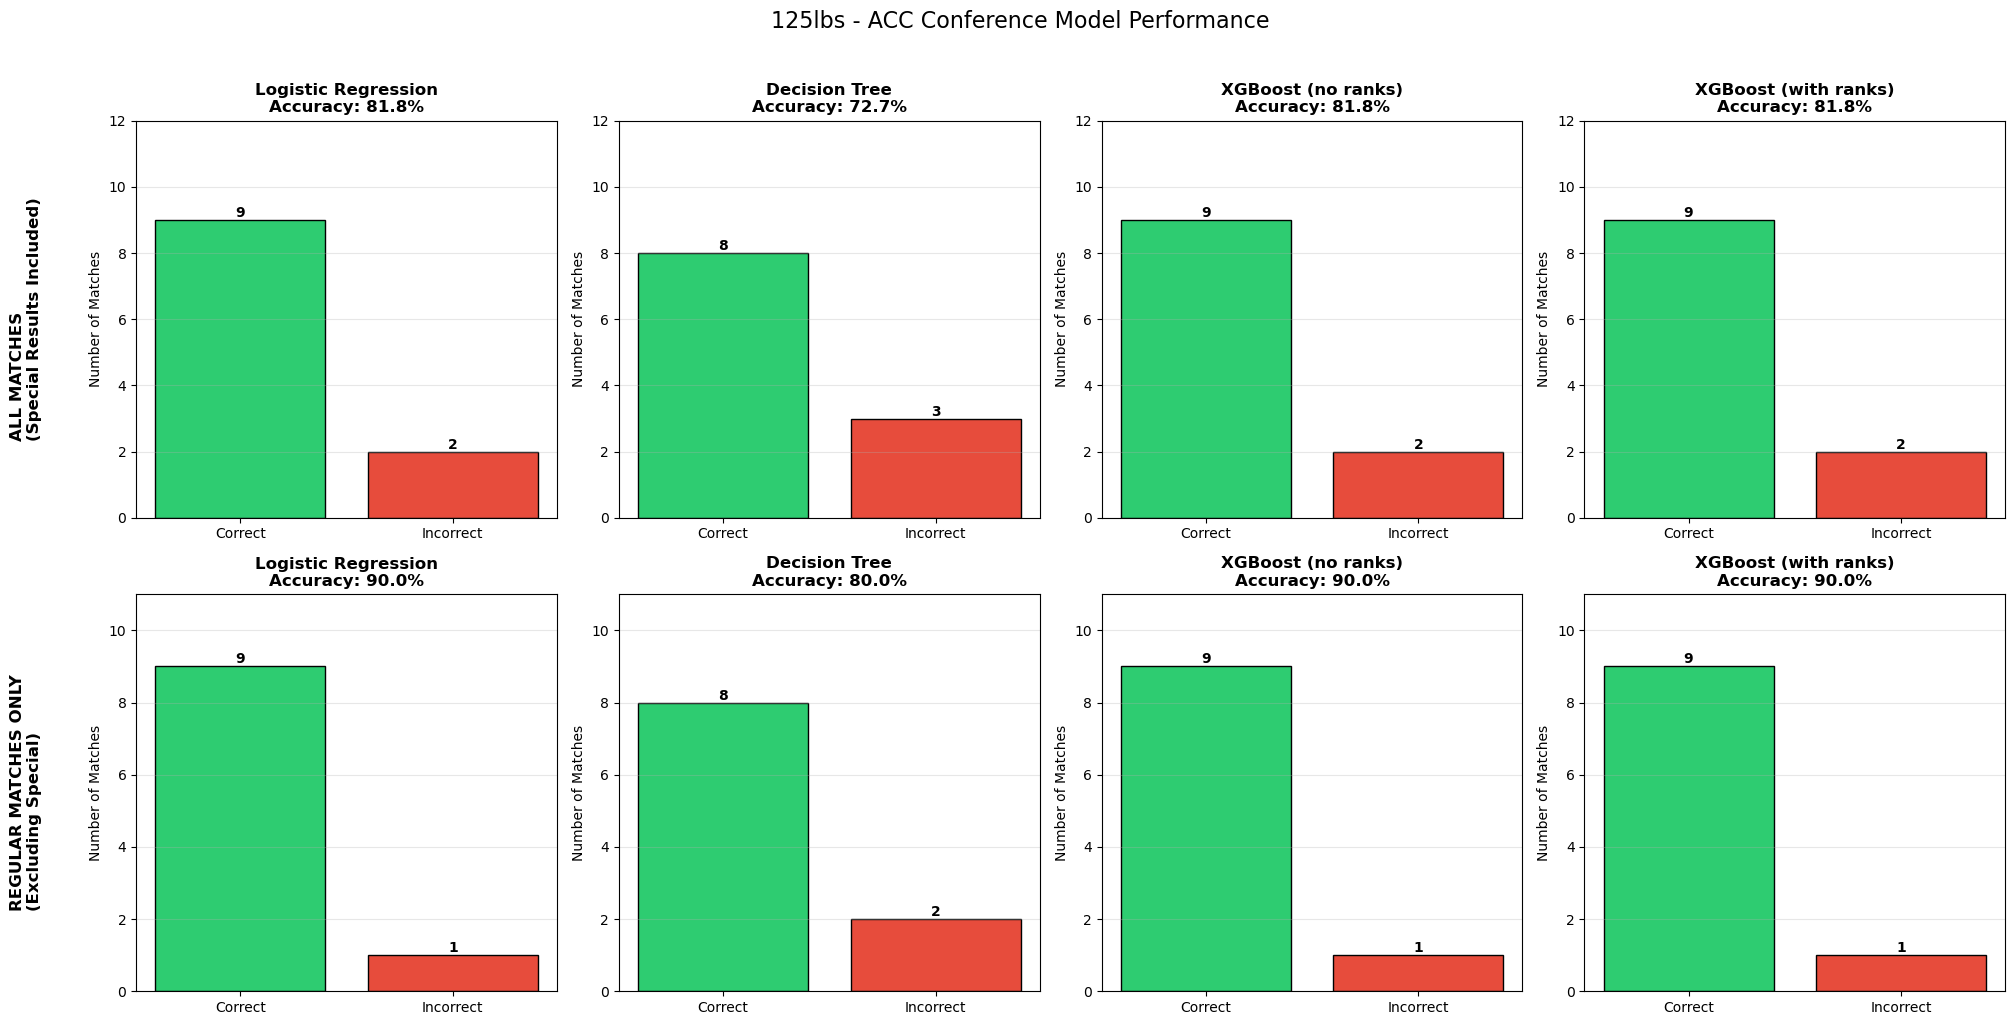


📊 MODEL RANKING - 125lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,81.8%,9/11
1,XGBoost (no ranks),81.8%,9/11
2,XGBoost (with ranks),81.8%,9/11
3,Decision Tree,72.7%,8/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,90.0%,9/10
1,XGBoost (no ranks),90.0%,9/10
2,XGBoost (with ranks),90.0%,9/10
3,Decision Tree,80.0%,8/10



📊 SUMMARY STATISTICS - 125lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,125lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,1 (9.1%)
6,Regular Matches,10 (90.9%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),81.8%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 125lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,81.8%,9/11,90.0%,9/10
1,Decision Tree,72.7%,8/11,80.0%,8/10
2,XGBoost (no ranks),81.8%,9/11,90.0%,9/10
3,XGBoost (with ranks),81.8%,9/11,90.0%,9/10



✅ 125lbs evaluation complete and added to overall results

📊 125lbs Quick Results:
   Logistic Regression: 9/10 (90.0%)
   Decision Tree: 8/10 (80.0%)
   XGBoost (no ranks): 9/10 (90.0%)
   XGBoost (with ranks): 9/10 (90.0%)


In [4]:
# ============================================
# ACTUAL RESULTS FOR 125lbs (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 125lbs ACC TOURNAMENT RESULTS")
print("="*100)

# 125lbs results with rounds
actual_results_125 = {
    # Quarterfinals
    ('Kysen Terukina', 'Tyler Chappell', 'Quarterfinal'): 'Kysen Terukina',  # Dec 4-3
    ('Keyveon Roller', 'Vincent Robinson', 'Quarterfinal'): 'Vincent Robinson',  # MD 10-2
    ('Spencer Von Savoye', 'Nico Provo', 'Quarterfinal'): 'Nico Provo',  # TF-1.5 17-2
    # Note: Eddie Ventresca had a bye - no match to record
    
    # Consolation Round 1
    ('Keyveon Roller', 'Spencer Von Savoye', 'Consolation Round 1'): 'Keyveon Roller',  # TF-1.5 20-4
    # Note: Tyler Chappell had a bye - no match to record
    
    # Semifinals
    ('Eddie Ventresca', 'Kysen Terukina', 'Semifinal'): 'Eddie Ventresca',  # TB-2 (RT) 2-2
    ('Nico Provo', 'Vincent Robinson', 'Semifinal'): 'Nico Provo',  # Dec 4-2
    
    # Consolation Semis
    ('Tyler Chappell', 'Vincent Robinson', 'Consolation Semi'): 'Vincent Robinson',  # Dec 2-1
    ('Keyveon Roller', 'Kysen Terukina', 'Consolation Semi'): 'Kysen Terukina',  # SV-1 4-1
    
    # 3rd Place Match
    ('Kysen Terukina', 'Vincent Robinson', '3rd Place Match'): 'Vincent Robinson',  # Dec 5-4
    
    # 5th Place Match - INJURY DEFAULT
    ('Keyveon Roller', 'Tyler Chappell', '5th Place Match'): 'Tyler Chappell',  # Injury default
    
    # Championship Final
    ('Eddie Ventresca', 'Nico Provo', 'Championship'): 'Eddie Ventresca',  # TB-1 2-1
}

# Track special matches (injury, forfeit, DQ)
special_matches_125 = [
    ('Keyveon Roller', 'Tyler Chappell', '5th Place Match')  # 5th place match - injury default
]

print(f"\n📊 125lbs Results Summary:")
print(f"   Total matches: {len(actual_results_125)}")
print(f"   Special matches: {len(special_matches_125)}")

# Display actual matches
actual_matches_df_125 = []
for (w1, w2, round_name), winner in actual_results_125.items():
    is_special = (w1, w2, round_name) in special_matches_125 or (w2, w1, round_name) in special_matches_125
    actual_matches_df_125.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

display(pd.DataFrame(actual_matches_df_125))

# Check for multiple meetings
matchup_counter = Counter()
for (w1, w2, _) in actual_results_125.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        print(f"   {matchup}: {matchup_counter[tuple(sorted(matchup.split(' vs ')))]} matches")
else:
    print("\n✅ No multiple meetings detected")

# ============================================
# EVALUATE 125lbs
# ============================================

# Store results from each weight class
all_weight_results = []

print("\n" + "="*100)
print("🔍 EVALUATING 125lbs")
print("="*100)

eval_125, summary_125 = evaluate_weight_class(
    weight_class=125,
    actual_results=actual_results_125,
    special_matches=special_matches_125,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_125:
    all_weight_results.append(summary_125)
    print("\n✅ 125lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 125lbs Quick Results:")
    for model, metrics in summary_125['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 125lbs evaluation failed")


# -- Run function with all weight classes


📋 SETTING UP 133lbs ACC TOURNAMENT RESULTS

📊 133lbs Results Summary:
   Total matches: 10
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Ethan Oakley,Evan Tallmadge,Evan Tallmadge,REGULAR
1,Quarterfinal,Marlon Yarbrough,Zach Redding,Zach Redding,REGULAR
2,Quarterfinal,Riley Rowan,Tyler Knox,Tyler Knox,REGULAR
3,Consolation Round 1,Riley Rowan,Marlon Yarbrough,Marlon Yarbrough,REGULAR
4,Semifinal,Aaron Seidel,Evan Tallmadge,Aaron Seidel,REGULAR
5,Semifinal,Tyler Knox,Zach Redding,Tyler Knox,REGULAR
6,Consolation Semi,Ethan Oakley,Zach Redding,Zach Redding,REGULAR
7,Consolation Semi,Evan Tallmadge,Marlon Yarbrough,Evan Tallmadge,REGULAR
8,3rd Place Match,Evan Tallmadge,Zach Redding,Zach Redding,REGULAR
9,Championship,Aaron Seidel,Tyler Knox,Aaron Seidel,REGULAR



🔍 EVALUATING 133lbs

🏋️  EVALUATING 133lbs - ACC CONFERENCE

📊 133lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 133lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Ethan Oakley,Evan Tallmadge,1 of 1,Evan Tallmadge,✅,53.6%,✅,74.7%,✅,54.5%,✅,64.6%
1,Quarterfinal,Marlon Yarbrough,Zach Redding,1 of 1,Zach Redding,✅,68.4%,✅,89.0%,✅,86.3%,✅,89.2%
2,Quarterfinal,Riley Rowan,Tyler Knox,1 of 1,Tyler Knox,✅,82.5%,✅,89.0%,✅,89.2%,✅,96.2%
3,Consolation Round 1,Riley Rowan,Marlon Yarbrough,1 of 1,Marlon Yarbrough,✅,57.0%,✅,61.1%,✅,63.8%,✅,83.3%
4,Semifinal,Aaron Seidel,Evan Tallmadge,1 of 1,Aaron Seidel,✅,62.4%,✅,74.6%,✅,69.0%,✅,71.6%
5,Semifinal,Tyler Knox,Zach Redding,1 of 1,Tyler Knox,✅,62.7%,❌,74.7%,❌,59.9%,❌,61.4%
6,Consolation Semi,Ethan Oakley,Zach Redding,1 of 1,Zach Redding,✅,55.2%,✅,74.7%,✅,61.1%,✅,78.2%
7,Consolation Semi,Evan Tallmadge,Marlon Yarbrough,1 of 1,Evan Tallmadge,✅,66.6%,✅,85.6%,✅,79.5%,✅,89.3%
8,3rd Place Match,Evan Tallmadge,Zach Redding,1 of 1,Zach Redding,✅,51.8%,✅,61.1%,✅,71.4%,✅,75.4%
9,Championship,Aaron Seidel,Tyler Knox,1 of 1,Aaron Seidel,❌,51.5%,✅,61.1%,✅,61.7%,✅,62.1%



📊 MODEL ACCURACY METRICS - 133lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,9/10,90.0%
1,Decision Tree,9/10,90.0%
2,XGBoost (no ranks),9/10,90.0%
3,XGBoost (with ranks),9/10,90.0%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,9/10,90.0%
1,Decision Tree,9/10,90.0%
2,XGBoost (no ranks),9/10,90.0%
3,XGBoost (with ranks),9/10,90.0%


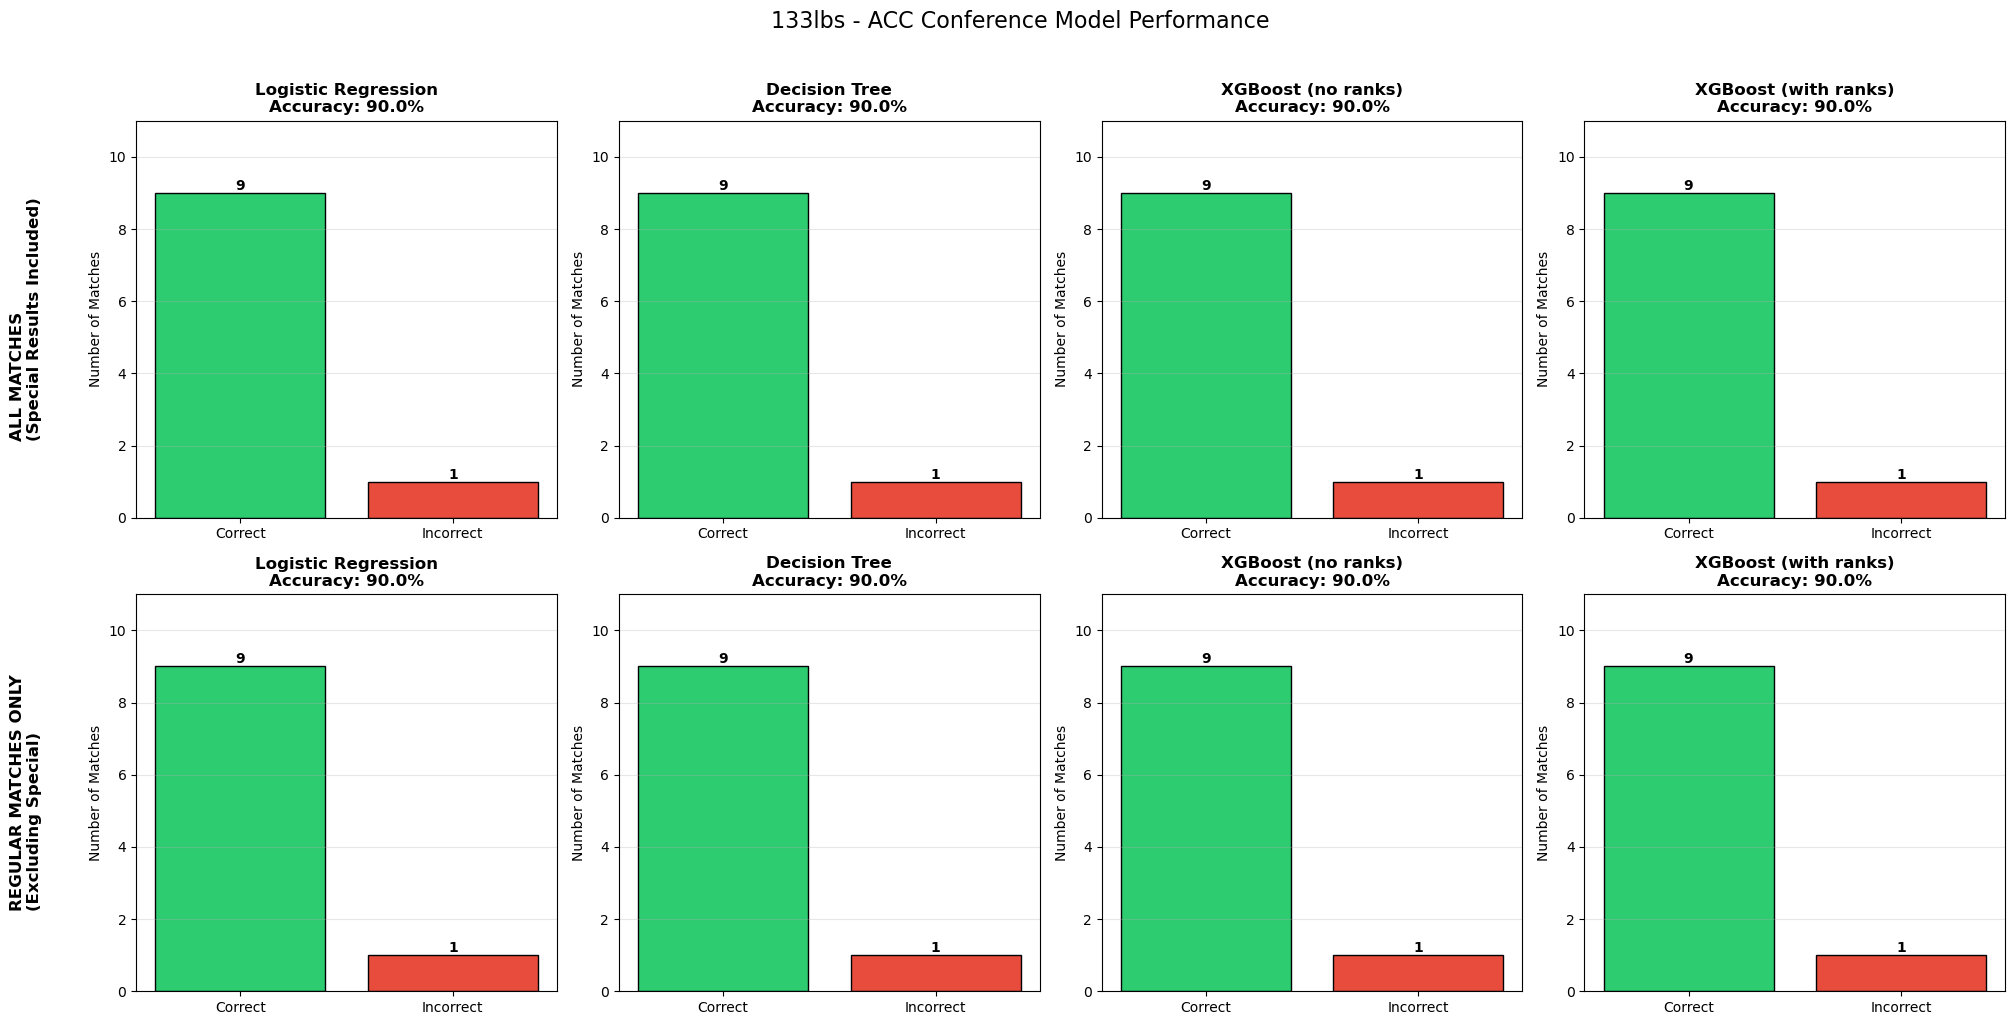


📊 MODEL RANKING - 133lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,90.0%,9/10
1,Decision Tree,90.0%,9/10
2,XGBoost (no ranks),90.0%,9/10
3,XGBoost (with ranks),90.0%,9/10



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,90.0%,9/10
1,Decision Tree,90.0%,9/10
2,XGBoost (no ranks),90.0%,9/10
3,XGBoost (with ranks),90.0%,9/10



📊 SUMMARY STATISTICS - 133lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,133lbs
2,Total Matches Evaluated,10
3,Unique Matchups,10
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,10 (100.0%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),90.0%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 133lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,90.0%,9/10,90.0%,9/10
1,Decision Tree,90.0%,9/10,90.0%,9/10
2,XGBoost (no ranks),90.0%,9/10,90.0%,9/10
3,XGBoost (with ranks),90.0%,9/10,90.0%,9/10



✅ 133lbs evaluation complete and added to overall results

📊 133lbs Quick Results:
   Logistic Regression: 9/10 (90.0%)
   Decision Tree: 9/10 (90.0%)
   XGBoost (no ranks): 9/10 (90.0%)
   XGBoost (with ranks): 9/10 (90.0%)



In [5]:
# ============================================
# 133lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 133lbs ACC TOURNAMENT RESULTS")
print("="*100)

actual_results_133 = {
    # Quarterfinals
    ('Ethan Oakley', 'Evan Tallmadge', 'Quarterfinal'): 'Evan Tallmadge',  # SV-1 4-1
    ('Marlon Yarbrough', 'Zach Redding', 'Quarterfinal'): 'Zach Redding',  # Dec 6-1
    ('Riley Rowan', 'Tyler Knox', 'Quarterfinal'): 'Tyler Knox',  # TF-1.5 16-1
    
    # Consolation Round 1
    ('Riley Rowan', 'Marlon Yarbrough', 'Consolation Round 1'): 'Marlon Yarbrough',  # Dec 7-0
    
    # Semifinals
    ('Aaron Seidel', 'Evan Tallmadge', 'Semifinal'): 'Aaron Seidel',  # TF-1.5 17-2
    ('Tyler Knox', 'Zach Redding', 'Semifinal'): 'Tyler Knox',  # MD 8-0
    
    # Consolation Semis
    ('Ethan Oakley', 'Zach Redding', 'Consolation Semi'): 'Zach Redding',  # MD 8-0
    ('Evan Tallmadge', 'Marlon Yarbrough', 'Consolation Semi'): 'Evan Tallmadge',  # Dec 5-3
    
    # 3rd Place Match
    ('Evan Tallmadge', 'Zach Redding', '3rd Place Match'): 'Zach Redding',  # Dec 5-4
    
    # Championship Final
    ('Aaron Seidel', 'Tyler Knox', 'Championship'): 'Aaron Seidel',  # TF-1.5 18-3
}

# Track special matches (injury, forfeit, DQ) - none for 133lbs based on the data
special_matches_133 = []  # No special matches mentioned

print(f"\n📊 133lbs Results Summary:")
print(f"   Total matches: {len(actual_results_133)}")
print(f"   Special matches: {len(special_matches_133)}")

# Display actual matches
actual_matches_df_133 = []
for (w1, w2, round_name), winner in actual_results_133.items():
    is_special = (w1, w2, round_name) in special_matches_133 or (w2, w1, round_name) in special_matches_133
    actual_matches_df_133.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

display(pd.DataFrame(actual_matches_df_133))

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_133.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        print(f"   {matchup}: {matchup_counter[tuple(sorted(matchup.split(' vs ')))]} matches")

# ============================================
# EVALUATE 133lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 133lbs")
print("="*100)

eval_133, summary_133 = evaluate_weight_class(
    weight_class=133,
    actual_results=actual_results_133,
    special_matches=special_matches_133,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_133:
    all_weight_results.append(summary_133)
    print("\n✅ 133lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 133lbs Quick Results:")
    for model, metrics in summary_133['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 133lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 141lbs ACC TOURNAMENT RESULTS

📊 141lbs Results Summary:
   Total matches: 11
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Briar Priest,Tom Crook,Briar Priest,REGULAR
1,Quarterfinal,Gable Porter,Ryan Jack,Ryan Jack,REGULAR
2,Quarterfinal,Luke Simcox,Raymond Adams,Luke Simcox,REGULAR
3,Consolation Round 1,Gable Porter,Raymond Adams,Gable Porter,REGULAR
4,Semifinal,Briar Priest,Jack Consiglio,Jack Consiglio,REGULAR
5,Semifinal,Luke Simcox,Ryan Jack,Luke Simcox,REGULAR
6,Consolation Semi,Ryan Jack,Tom Crook,Ryan Jack,REGULAR
7,Consolation Semi,Briar Priest,Gable Porter,Gable Porter,REGULAR
8,3rd Place Match,Gable Porter,Ryan Jack,Ryan Jack,REGULAR
9,5th Place Match,Briar Priest,Tom Crook,Tom Crook,REGULAR



⚠️ Multiple meetings detected:
   Briar Priest vs Tom Crook: 2 matches
   Gable Porter vs Ryan Jack: 2 matches

🔍 EVALUATING 141lbs

🏋️  EVALUATING 141lbs - ACC CONFERENCE

📊 141lbs predictions in dataset: 21 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Briar Priest vs Tom Crook: 2 matches
      Rounds: Quarterfinal, 5th Place Match
   Gable Porter vs Ryan Jack: 2 matches
      Rounds: Quarterfinal, 3rd Place Match

📊 DETAILED EVALUATION - 141lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Briar Priest,Tom Crook,1 of 1,Briar Priest,✅,58.7%,❌,61.1%,❌,53.2%,❌,67.6%
1,Quarterfinal,Gable Porter,Ryan Jack,1 of 1,Ryan Jack,❌,54.2%,❌,53.1%,✅,56.3%,✅,82.9%
2,Quarterfinal,Luke Simcox,Raymond Adams,1 of 1,Luke Simcox,✅,70.2%,✅,74.6%,✅,74.8%,✅,86.5%
3,Consolation Round 1,Gable Porter,Raymond Adams,1 of 1,Gable Porter,✅,78.2%,✅,89.0%,✅,84.8%,✅,92.8%
4,Semifinal,Briar Priest,Jack Consiglio,1 of 1,Jack Consiglio,✅,53.1%,❌,53.1%,❌,52.4%,✅,51.3%
5,Semifinal,Luke Simcox,Ryan Jack,1 of 1,Luke Simcox,❌,56.3%,❌,61.1%,❌,78.1%,❌,89.8%
6,Consolation Semi,Ryan Jack,Tom Crook,1 of 1,Ryan Jack,✅,63.0%,✅,70.0%,✅,65.3%,✅,81.9%
7,Consolation Semi,Briar Priest,Gable Porter,1 of 1,Gable Porter,✅,59.2%,✅,61.1%,✅,66.1%,❌,53.8%
8,3rd Place Match,Gable Porter,Ryan Jack,2 of 2,Ryan Jack,❌,54.2%,❌,53.1%,✅,56.3%,✅,82.9%
9,5th Place Match,Briar Priest,Tom Crook,2 of 2,Tom Crook,❌,58.7%,✅,61.1%,✅,53.2%,✅,67.6%



📊 MODEL ACCURACY METRICS - 141lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,7/11,63.6%
1,Decision Tree,6/11,54.5%
2,XGBoost (no ranks),8/11,72.7%
3,XGBoost (with ranks),8/11,72.7%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,7/11,63.6%
1,Decision Tree,6/11,54.5%
2,XGBoost (no ranks),8/11,72.7%
3,XGBoost (with ranks),8/11,72.7%


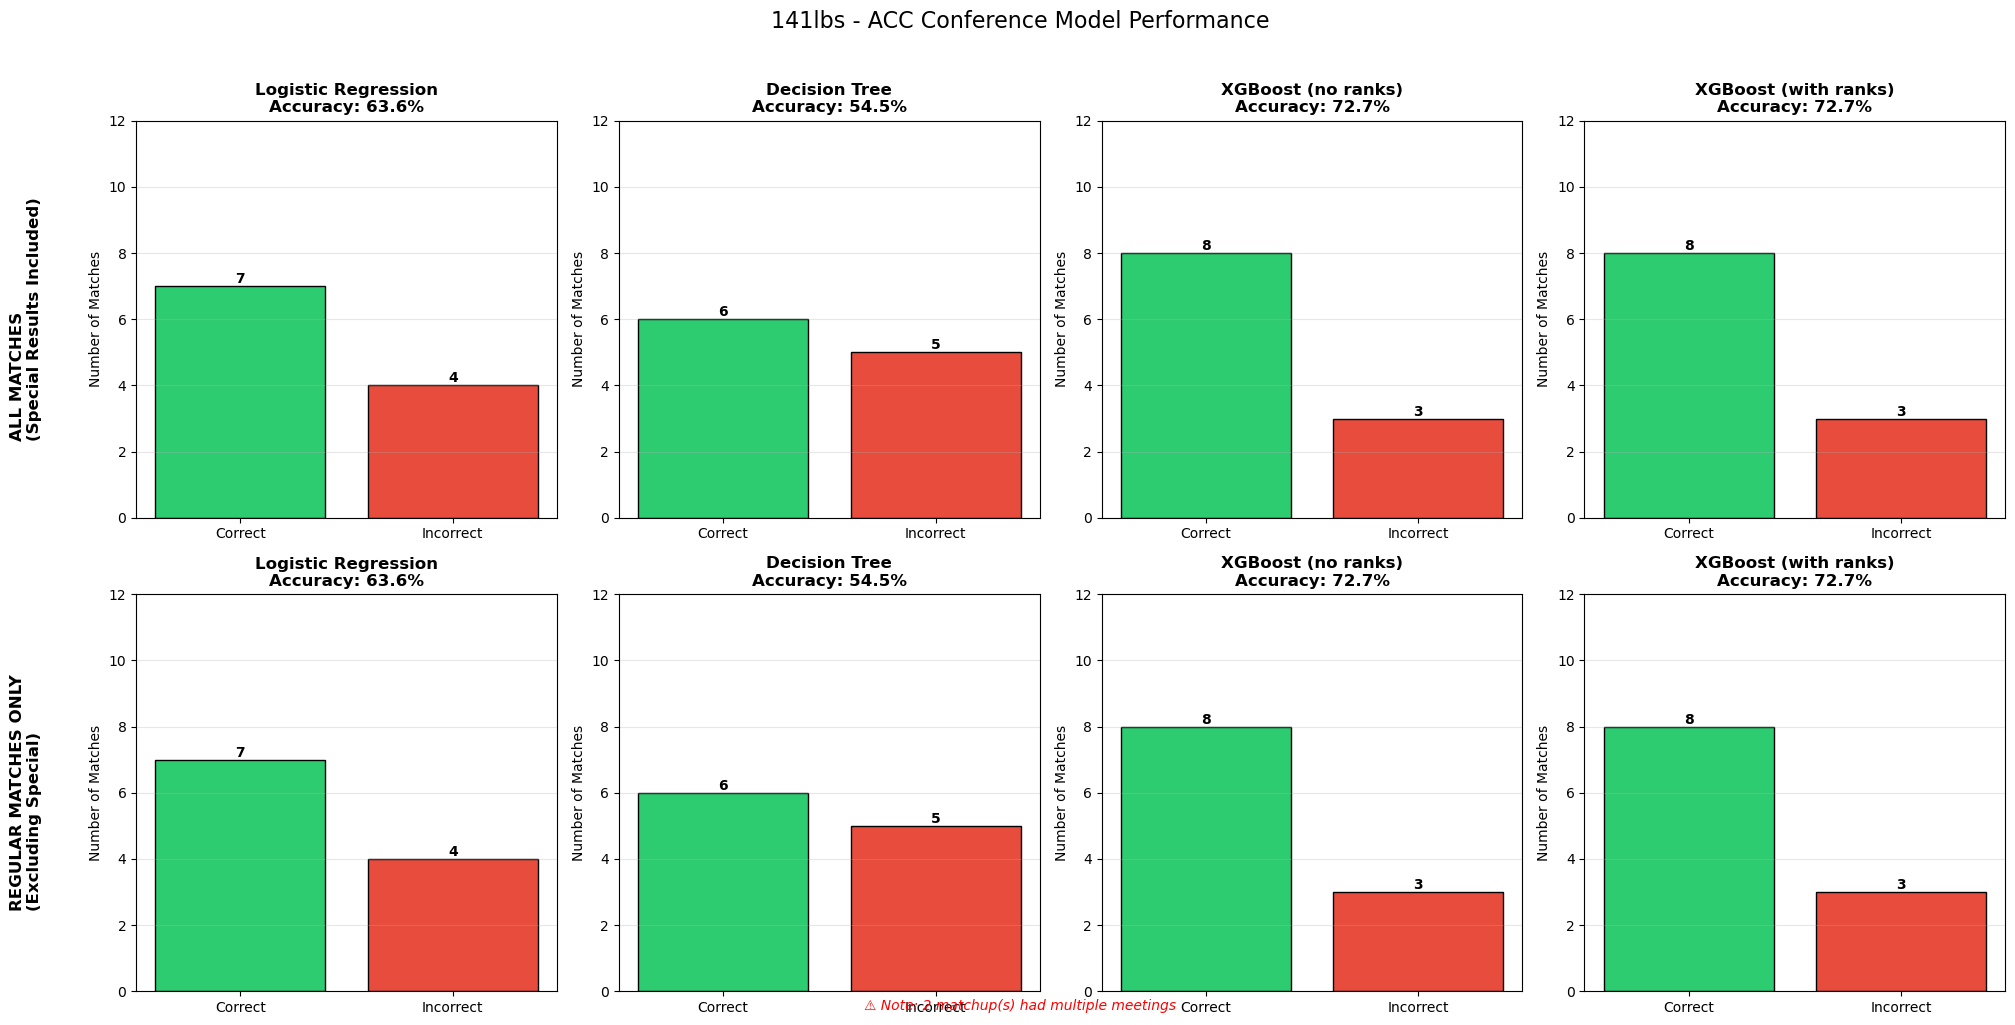


📊 MODEL RANKING - 141lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (no ranks),72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Logistic Regression,63.6%,7/11
3,Decision Tree,54.5%,6/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (no ranks),72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Logistic Regression,63.6%,7/11
3,Decision Tree,54.5%,6/11



📊 SUMMARY STATISTICS - 141lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,141lbs
2,Total Matches Evaluated,11
3,Unique Matchups,9
4,Matchups with Multiple Meetings,2
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,11 (100.0%)
7,Best Model (All Matches),XGBoost (no ranks)
8,Best Model Accuracy (All Matches),72.7%
9,Best Model (Regular Only),XGBoost (no ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 141lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,63.6%,7/11,63.6%,7/11
1,Decision Tree,54.5%,6/11,54.5%,6/11
2,XGBoost (no ranks),72.7%,8/11,72.7%,8/11
3,XGBoost (with ranks),72.7%,8/11,72.7%,8/11



✅ 141lbs evaluation complete and added to overall results

📊 141lbs Quick Results:
   Logistic Regression: 7/11 (63.6%)
   Decision Tree: 6/11 (54.5%)
   XGBoost (no ranks): 8/11 (72.7%)
   XGBoost (with ranks): 8/11 (72.7%)


In [6]:
# ============================================
# 141lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 141lbs ACC TOURNAMENT RESULTS")
print("="*100)

actual_results_141 = {
    # Quarterfinals
    ('Briar Priest', 'Tom Crook', 'Quarterfinal'): 'Briar Priest',  # Fall 7:10
    ('Gable Porter', 'Ryan Jack', 'Quarterfinal'): 'Ryan Jack',  # Dec 9-3
    ('Luke Simcox', 'Raymond Adams', 'Quarterfinal'): 'Luke Simcox',  # Fall 5:59
    # Note: Jack Consiglio had a bye - no match to record
    
    # Consolation Round 1
    ('Gable Porter', 'Raymond Adams', 'Consolation Round 1'): 'Gable Porter',  # MD 11-3
    # Note: Tom Crook had a bye - no match to record
    
    # Semifinals
    ('Briar Priest', 'Jack Consiglio', 'Semifinal'): 'Jack Consiglio',  # Dec 5-4
    ('Luke Simcox', 'Ryan Jack', 'Semifinal'): 'Luke Simcox',  # Dec 6-5
    
    # Consolation Semis
    ('Ryan Jack', 'Tom Crook', 'Consolation Semi'): 'Ryan Jack',  # MD 10-2
    ('Briar Priest', 'Gable Porter', 'Consolation Semi'): 'Gable Porter',  # Dec 8-6
    
    # 3rd Place Match
    ('Gable Porter', 'Ryan Jack', '3rd Place Match'): 'Ryan Jack',  # SV-1 4-1
    
    # 5th Place Match
    ('Briar Priest', 'Tom Crook', '5th Place Match'): 'Tom Crook',  # Dec 4-1
    
    # Championship Final
    ('Jack Consiglio', 'Luke Simcox', 'Championship'): 'Jack Consiglio',  # Dec 4-3
}

# Track special matches (injury, forfeit, DQ)
special_matches_141 = []  # No special matches in 141lbs

print(f"\n📊 141lbs Results Summary:")
print(f"   Total matches: {len(actual_results_141)}")
print(f"   Special matches: {len(special_matches_141)}")

# Display actual matches
actual_matches_df_141 = []
for (w1, w2, round_name), winner in actual_results_141.items():
    is_special = (w1, w2, round_name) in special_matches_141 or (w2, w1, round_name) in special_matches_141
    actual_matches_df_141.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

display(pd.DataFrame(actual_matches_df_141))

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_141.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        print(f"   {matchup}: {matchup_counter[tuple(sorted(matchup.split(' vs ')))]} matches")

# ============================================
# EVALUATE 141lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 141lbs")
print("="*100)

eval_141, summary_141 = evaluate_weight_class(
    weight_class=141,
    actual_results=actual_results_141,
    special_matches=special_matches_141,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_141:
    all_weight_results.append(summary_141)
    print("\n✅ 141lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 141lbs Quick Results:")
    for model, metrics in summary_141['regular_metrics'].items():
        print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 141lbs evaluation failed")


📋 SETTING UP 149lbs ACC TOURNAMENT RESULTS

📊 149lbs Results Summary:
   Total matches: 11
   Special matches: 2


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Kade Brown,Wynton Denkins,Kade Brown,REGULAR
1,Quarterfinal,Collin Gaj,Dylan Ross,Collin Gaj,REGULAR
2,Quarterfinal,Aden Valencia,Nate Askew,Aden Valencia,REGULAR
3,Consolation Round 1,Dylan Ross,Nate Askew,Dylan Ross,REGULAR
4,Semifinal,Koy Buesgens,Kade Brown,Koy Buesgens,REGULAR
5,Semifinal,Collin Gaj,Aden Valencia,Collin Gaj,REGULAR
6,Consolation Semi,Aden Valencia,Wynton Denkins,Aden Valencia,REGULAR
7,Consolation Semi,Kade Brown,Dylan Ross,Kade Brown,SPECIAL
8,3rd Place Match,Aden Valencia,Kade Brown,Aden Valencia,REGULAR
9,5th Place Match,Wynton Denkins,Dylan Ross,Wynton Denkins,SPECIAL



✅ No multiple meetings detected

🔍 EVALUATING 149lbs

🏋️  EVALUATING 149lbs - ACC CONFERENCE

📊 149lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 149lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Kade Brown,Wynton Denkins,1 of 1,Kade Brown,✅,54.2%,✅,61.1%,✅,59.9%,✅,63.2%
1,Quarterfinal,Collin Gaj,Dylan Ross,1 of 1,Collin Gaj,✅,51.1%,✅,61.1%,✅,62.4%,✅,91.0%
2,Quarterfinal,Aden Valencia,Nate Askew,1 of 1,Aden Valencia,✅,61.6%,✅,74.6%,✅,76.5%,✅,79.7%
3,Consolation Round 1,Dylan Ross,Nate Askew,1 of 1,Dylan Ross,❌,51.2%,✅,61.1%,✅,63.7%,❌,88.0%
4,Semifinal,Koy Buesgens,Kade Brown,1 of 1,Koy Buesgens,✅,63.0%,✅,74.6%,✅,81.2%,✅,78.7%
5,Semifinal,Collin Gaj,Aden Valencia,1 of 1,Collin Gaj,❌,61.7%,❌,74.7%,❌,74.4%,❌,80.4%
6,Consolation Semi,Aden Valencia,Wynton Denkins,1 of 1,Aden Valencia,✅,55.5%,✅,61.1%,✅,57.7%,✅,58.7%
7,Consolation Semi,Kade Brown,Dylan Ross,1 of 1,Kade Brown,✅,61.7%,✅,74.6%,✅,75.6%,✅,93.4%
8,3rd Place Match,Aden Valencia,Kade Brown,1 of 1,Aden Valencia,✅,51.6%,✅,61.1%,✅,66.4%,✅,74.8%
9,5th Place Match,Wynton Denkins,Dylan Ross,1 of 1,Wynton Denkins,✅,57.9%,✅,61.1%,✅,66.1%,✅,91.8%



📊 MODEL ACCURACY METRICS - 149lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,9/11,81.8%
2,XGBoost (no ranks),9/11,81.8%
3,XGBoost (with ranks),8/11,72.7%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,6/9,66.7%
1,Decision Tree,7/9,77.8%
2,XGBoost (no ranks),7/9,77.8%
3,XGBoost (with ranks),6/9,66.7%


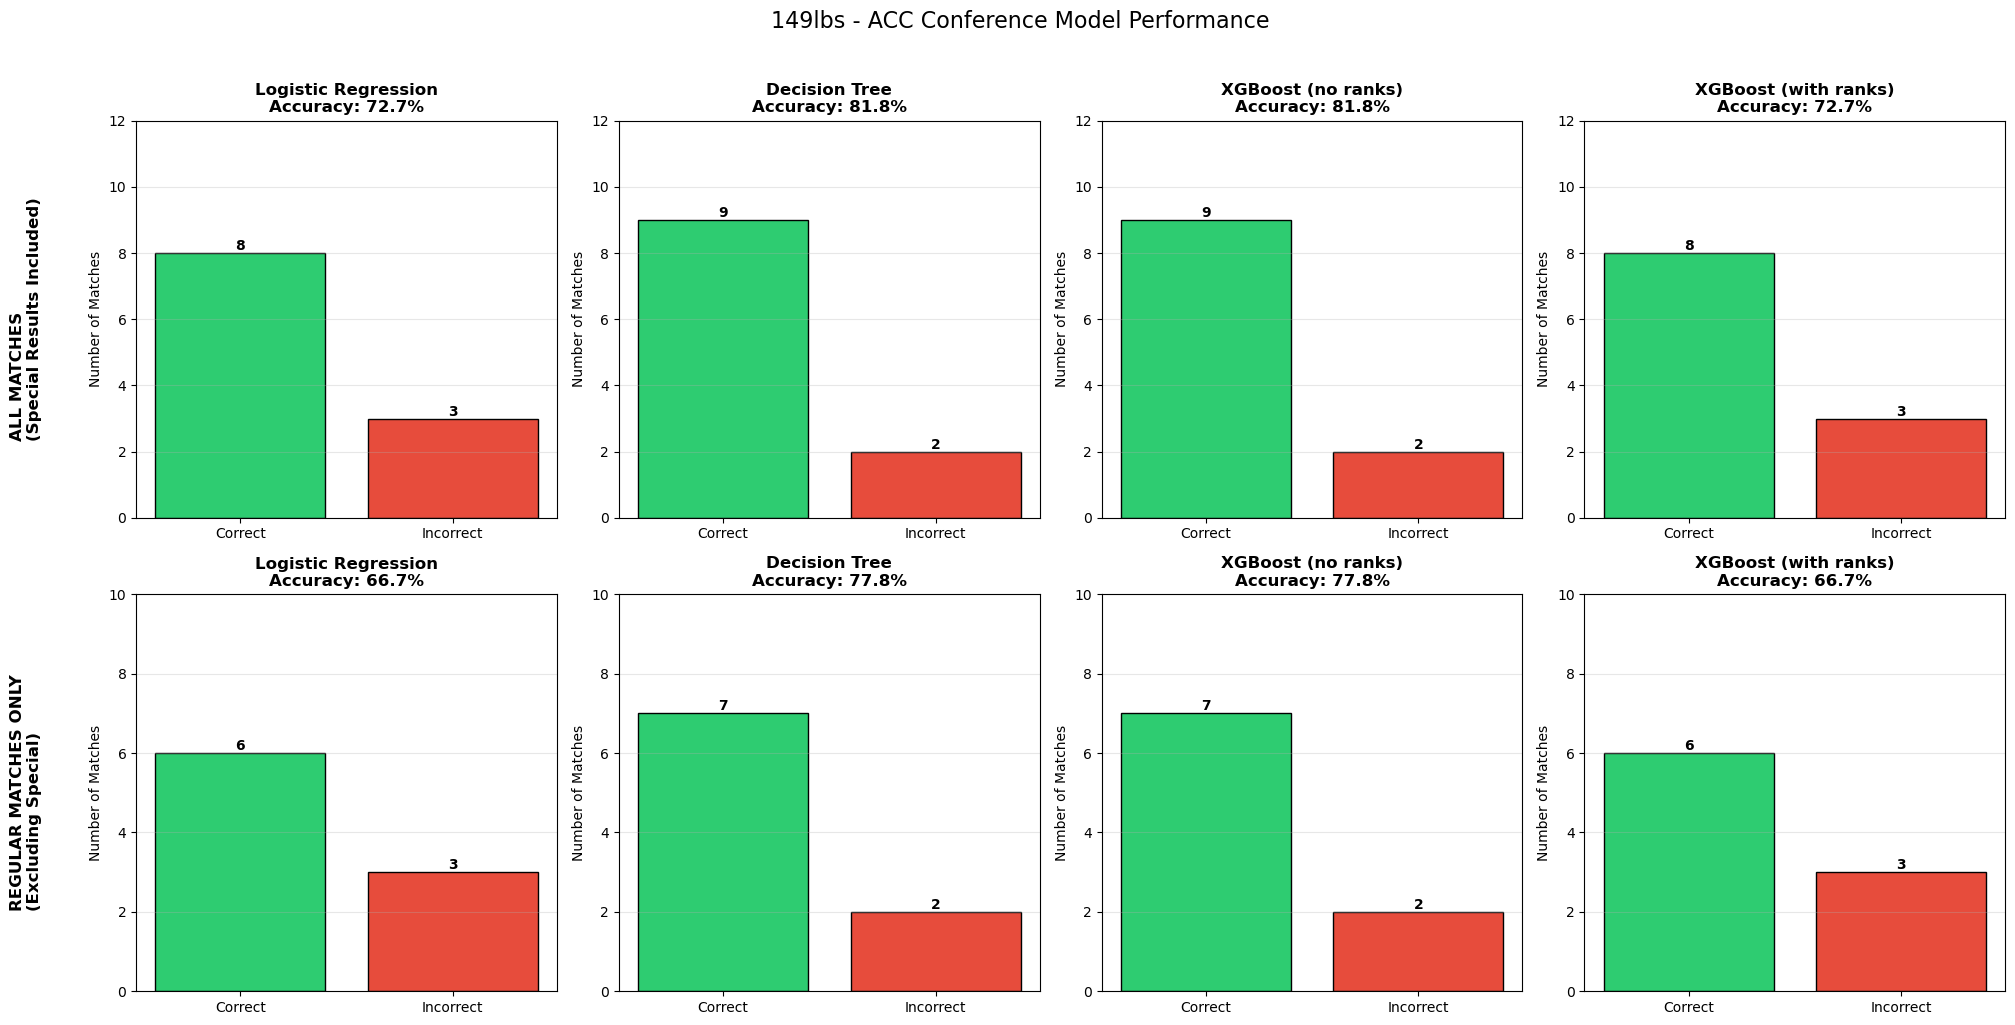


📊 MODEL RANKING - 149lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Decision Tree,81.8%,9/11
1,XGBoost (no ranks),81.8%,9/11
2,Logistic Regression,72.7%,8/11
3,XGBoost (with ranks),72.7%,8/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Decision Tree,77.8%,7/9
1,XGBoost (no ranks),77.8%,7/9
2,Logistic Regression,66.7%,6/9
3,XGBoost (with ranks),66.7%,6/9



📊 SUMMARY STATISTICS - 149lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,149lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,2 (18.2%)
6,Regular Matches,9 (81.8%)
7,Best Model (All Matches),Decision Tree
8,Best Model Accuracy (All Matches),81.8%
9,Best Model (Regular Only),Decision Tree



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 149lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,72.7%,8/11,66.7%,6/9
1,Decision Tree,81.8%,9/11,77.8%,7/9
2,XGBoost (no ranks),81.8%,9/11,77.8%,7/9
3,XGBoost (with ranks),72.7%,8/11,66.7%,6/9



✅ 149lbs evaluation complete and added to overall results

📊 149lbs Quick Results:
   Logistic Regression: 6/9 (66.7%)
   Decision Tree: 7/9 (77.8%)
   XGBoost (no ranks): 7/9 (77.8%)
   XGBoost (with ranks): 6/9 (66.7%)

⚠️ Special matches in this weight class: 2
   - Consolation Semi: Kade Brown vs Dylan Ross
   - 5th Place Match: Wynton Denkins vs Dylan Ross



In [7]:
# ============================================
# 149lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 149lbs ACC TOURNAMENT RESULTS")
print("="*100)

actual_results_149 = {
    # Quarterfinals
    ('Kade Brown', 'Wynton Denkins', 'Quarterfinal'): 'Kade Brown',  # Dec 4-1
    ('Collin Gaj', 'Dylan Ross', 'Quarterfinal'): 'Collin Gaj',  # Dec 5-0
    ('Aden Valencia', 'Nate Askew', 'Quarterfinal'): 'Aden Valencia',  # TF-1.5 18-3
    # Note: Koy Buesgens had a bye - no match to record
    
    # Consolation Round 1
    ('Dylan Ross', 'Nate Askew', 'Consolation Round 1'): 'Dylan Ross',  # Dec 2-1
    
    # Semifinals
    ('Koy Buesgens', 'Kade Brown', 'Semifinal'): 'Koy Buesgens',  # Dec 6-2
    ('Collin Gaj', 'Aden Valencia', 'Semifinal'): 'Collin Gaj',  # Dec 5-4
    
    # Consolation Semis
    ('Aden Valencia', 'Wynton Denkins', 'Consolation Semi'): 'Aden Valencia',  # Dec 7-2
    ('Kade Brown', 'Dylan Ross', 'Consolation Semi'): 'Kade Brown',  # Injury default (Inj. 5:47)
    
    # 3rd Place Match
    ('Aden Valencia', 'Kade Brown', '3rd Place Match'): 'Aden Valencia',  # MD 11-0
    
    # 5th Place Match - MEDICAL FORFEIT
    ('Wynton Denkins', 'Dylan Ross', '5th Place Match'): 'Wynton Denkins',  # Medical forfeit
    
    # Championship Final
    ('Collin Gaj', 'Koy Buesgens', 'Championship'): 'Collin Gaj',  # TB-1 2-1
}

# Track special matches (injury, forfeit, DQ)
special_matches_149 = [
    ('Kade Brown', 'Dylan Ross', 'Consolation Semi'),  # Injury default
    ('Wynton Denkins', 'Dylan Ross', '5th Place Match'),  # Medical forfeit
]

print(f"\n📊 149lbs Results Summary:")
print(f"   Total matches: {len(actual_results_149)}")
print(f"   Special matches: {len(special_matches_149)}")

# Display actual matches
actual_matches_df_149 = []
for (w1, w2, round_name), winner in actual_results_149.items():
    is_special = (w1, w2, round_name) in special_matches_149 or (w2, w1, round_name) in special_matches_149
    actual_matches_df_149.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', '5th Place Match', 'Championship']
actual_matches_df_149 = pd.DataFrame(actual_matches_df_149)
actual_matches_df_149['Round Order'] = actual_matches_df_149['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_149 = actual_matches_df_149.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_149)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_149.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_149.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# ============================================
# EVALUATE 149lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 149lbs")
print("="*100)

eval_149, summary_149 = evaluate_weight_class(
    weight_class=149,
    actual_results=actual_results_149,
    special_matches=special_matches_149,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_149:
    all_weight_results.append(summary_149)
    print("\n✅ 149lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 149lbs Quick Results:")
    if 'regular_metrics' in summary_149 and summary_149['regular_metrics']:
        for model, metrics in summary_149['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    else:
        print("   No regular matches to evaluate")
    
    # Show special matches info
    print(f"\n⚠️ Special matches in this weight class: {len(special_matches_149)}")
    for (w1, w2, round_name) in special_matches_149:
        print(f"   - {round_name}: {w1} vs {w2}")
else:
    print("\n⚠️ 149lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 157lbs ACC TOURNAMENT RESULTS

📊 157lbs Results Summary:
   Total matches: 11
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Laird Root,Colton Washleski,Laird Root,REGULAR
1,Quarterfinal,Dylan Evans,Luca Felix,Dylan Evans,REGULAR
2,Quarterfinal,Ethen Miller,Mikey Boulanger,Ethen Miller,REGULAR
3,Consolation Round 1,Mikey Boulanger,Luca Felix,Mikey Boulanger,REGULAR
4,Semifinal,Daniel Cardenas,Laird Root,Daniel Cardenas,REGULAR
5,Semifinal,Ethen Miller,Dylan Evans,Ethen Miller,REGULAR
6,Consolation Semi,Colton Washleski,Dylan Evans,Colton Washleski,REGULAR
7,Consolation Semi,Laird Root,Mikey Boulanger,Laird Root,REGULAR
8,3rd Place Match,Colton Washleski,Laird Root,Colton Washleski,REGULAR
9,5th Place Match,Dylan Evans,Mikey Boulanger,Dylan Evans,REGULAR



⚠️ Multiple meetings detected:
   Colton Washleski vs Laird Root: 2 matches
      Rounds:
        - Quarterfinal: Laird Root wins
        - 3rd Place Match: Colton Washleski wins

🔍 Checking for potential multiple meetings:
✅ Found: Laird Root vs Colton Washleski - 2 matches
   - Quarterfinal: Laird Root wins
   - 3rd Place Match: Colton Washleski wins

🔍 EVALUATING 157lbs

🏋️  EVALUATING 157lbs - ACC CONFERENCE

📊 157lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 157lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Laird Root,Colton Washleski,1 of 1,Laird Root,❌,56.0%,✅,61.1%,❌,58.0%,❌,57.2%
1,Quarterfinal,Dylan Evans,Luca Felix,1 of 1,Dylan Evans,✅,67.4%,✅,89.0%,✅,87.7%,✅,86.2%
2,Quarterfinal,Ethen Miller,Mikey Boulanger,1 of 1,Ethen Miller,✅,74.3%,✅,74.6%,✅,81.5%,✅,94.9%
3,Consolation Round 1,Mikey Boulanger,Luca Felix,1 of 1,Mikey Boulanger,❌,51.3%,❌,61.1%,❌,56.1%,❌,80.1%
4,Semifinal,Daniel Cardenas,Laird Root,1 of 1,Daniel Cardenas,✅,69.7%,✅,74.6%,✅,83.6%,✅,90.9%
5,Semifinal,Ethen Miller,Dylan Evans,1 of 1,Ethen Miller,✅,57.6%,❌,74.7%,❌,58.3%,✅,55.4%
6,Consolation Semi,Colton Washleski,Dylan Evans,1 of 1,Colton Washleski,❌,52.6%,❌,61.1%,❌,52.4%,❌,81.5%
7,Consolation Semi,Laird Root,Mikey Boulanger,1 of 1,Laird Root,✅,60.3%,✅,74.6%,✅,76.0%,✅,92.2%
8,3rd Place Match,Colton Washleski,Laird Root,1 of 1,Colton Washleski,✅,56.0%,❌,61.1%,✅,58.0%,✅,57.2%
9,5th Place Match,Dylan Evans,Mikey Boulanger,1 of 1,Dylan Evans,✅,68.3%,✅,89.0%,✅,83.4%,✅,94.9%



📊 MODEL ACCURACY METRICS - 157lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,7/11,63.6%
2,XGBoost (no ranks),7/11,63.6%
3,XGBoost (with ranks),8/11,72.7%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,7/11,63.6%
2,XGBoost (no ranks),7/11,63.6%
3,XGBoost (with ranks),8/11,72.7%


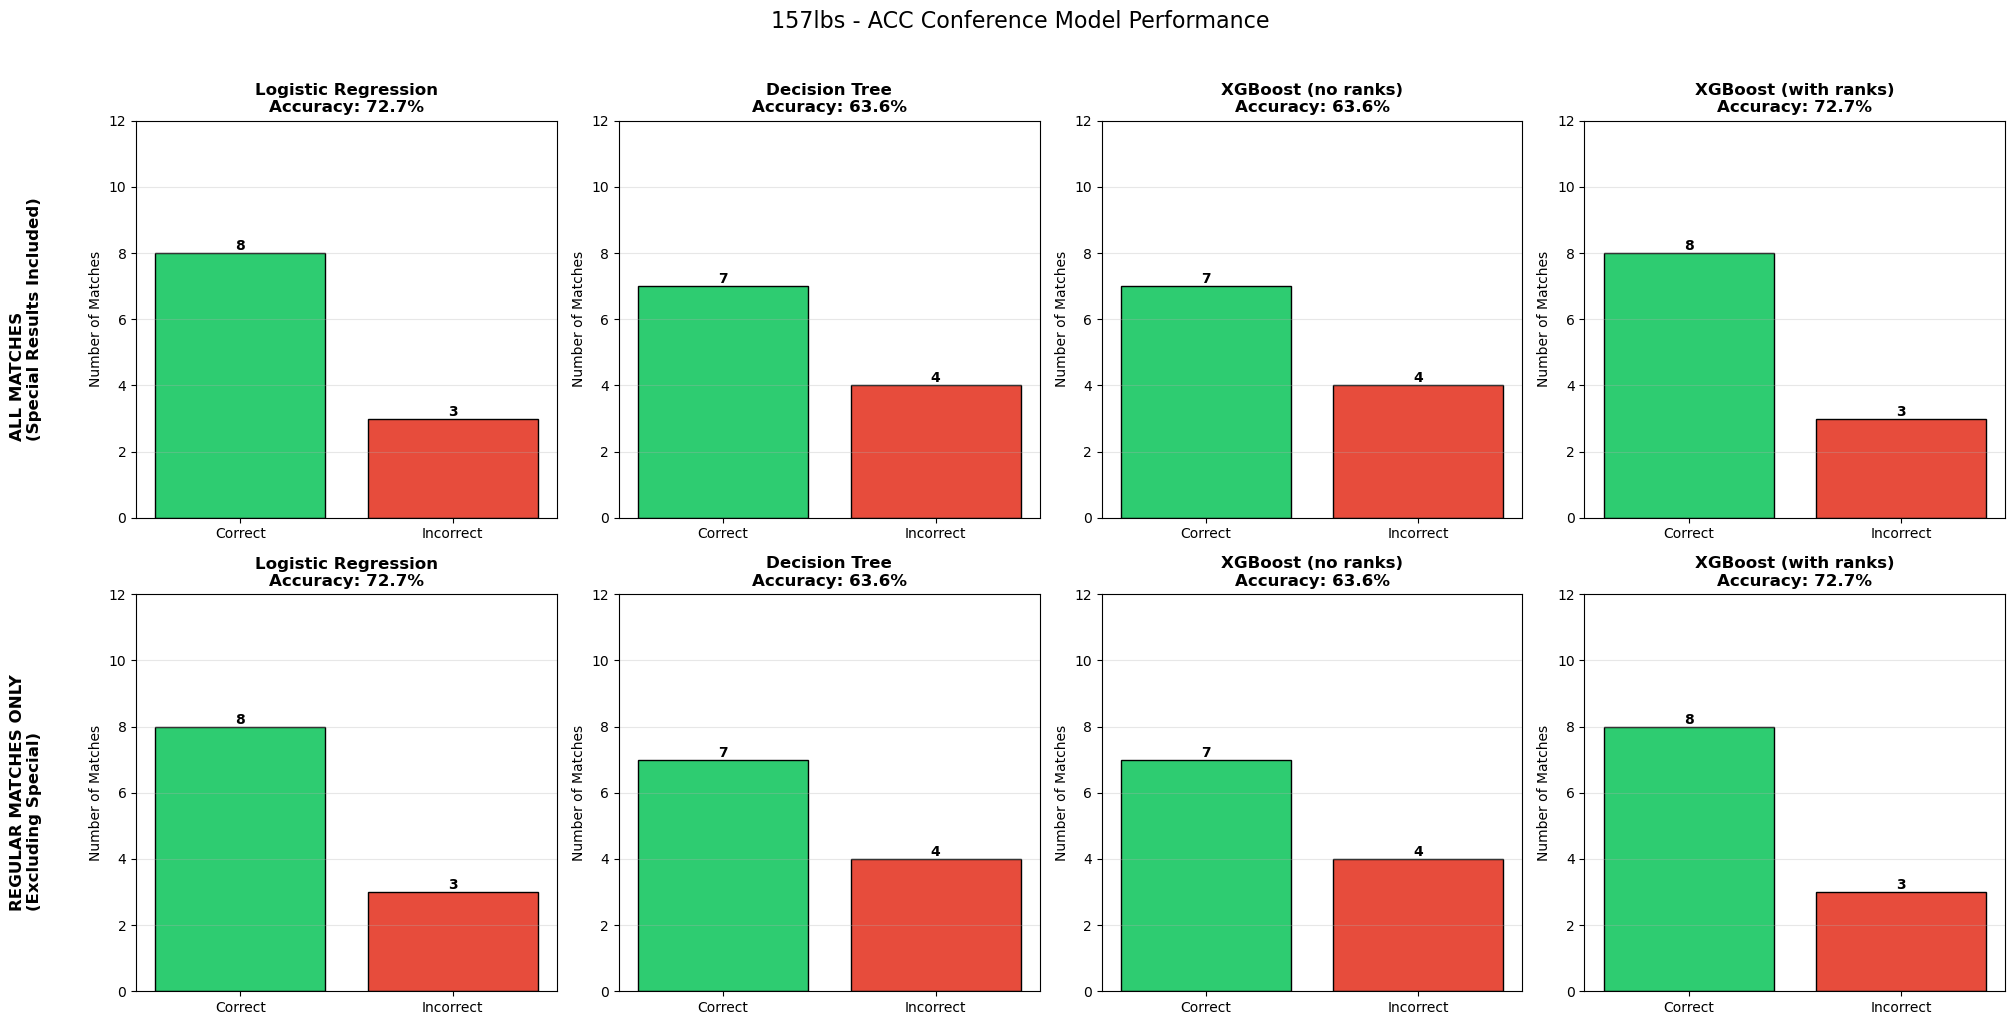


📊 MODEL RANKING - 157lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Decision Tree,63.6%,7/11
3,XGBoost (no ranks),63.6%,7/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Decision Tree,63.6%,7/11
3,XGBoost (no ranks),63.6%,7/11



📊 SUMMARY STATISTICS - 157lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,157lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,11 (100.0%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),72.7%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 157lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,72.7%,8/11,72.7%,8/11
1,Decision Tree,63.6%,7/11,63.6%,7/11
2,XGBoost (no ranks),63.6%,7/11,63.6%,7/11
3,XGBoost (with ranks),72.7%,8/11,72.7%,8/11



✅ 157lbs evaluation complete and added to overall results

📊 157lbs Quick Results:
   Logistic Regression: 8/11 (72.7%)
   Decision Tree: 7/11 (63.6%)
   XGBoost (no ranks): 7/11 (63.6%)
   XGBoost (with ranks): 8/11 (72.7%)



In [8]:
# ============================================
# 157lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 157lbs ACC TOURNAMENT RESULTS")
print("="*100)

actual_results_157 = {
    # Quarterfinals
    ('Laird Root', 'Colton Washleski', 'Quarterfinal'): 'Laird Root',  # TB-1 4-1
    ('Dylan Evans', 'Luca Felix', 'Quarterfinal'): 'Dylan Evans',  # MD 14-3
    ('Ethen Miller', 'Mikey Boulanger', 'Quarterfinal'): 'Ethen Miller',  # MD 13-3
    # Note: Daniel Cardenas had a bye - no match to record
    
    # Consolation Round 1
    ('Mikey Boulanger', 'Luca Felix', 'Consolation Round 1'): 'Mikey Boulanger',  # MD 11-0
    
    # Semifinals
    ('Daniel Cardenas', 'Laird Root', 'Semifinal'): 'Daniel Cardenas',  # MD 8-0
    ('Ethen Miller', 'Dylan Evans', 'Semifinal'): 'Ethen Miller',  # Dec 4-3
    
    # Consolation Semis
    ('Colton Washleski', 'Dylan Evans', 'Consolation Semi'): 'Colton Washleski',  # Dec 5-2
    ('Laird Root', 'Mikey Boulanger', 'Consolation Semi'): 'Laird Root',  # Fall 0:53
    
    # 3rd Place Match
    ('Colton Washleski', 'Laird Root', '3rd Place Match'): 'Colton Washleski',  # Dec 4-2
    
    # 5th Place Match
    ('Dylan Evans', 'Mikey Boulanger', '5th Place Match'): 'Dylan Evans',  # MD 14-3
    
    # Championship Final
    ('Daniel Cardenas', 'Ethen Miller', 'Championship'): 'Daniel Cardenas',  # Dec 5-2
}

# Track special matches (injury, forfeit, DQ) - none for 157lbs
special_matches_157 = []  # No special matches mentioned

print(f"\n📊 157lbs Results Summary:")
print(f"   Total matches: {len(actual_results_157)}")
print(f"   Special matches: {len(special_matches_157)}")

# Display actual matches
actual_matches_df_157 = []
for (w1, w2, round_name), winner in actual_results_157.items():
    is_special = (w1, w2, round_name) in special_matches_157 or (w2, w1, round_name) in special_matches_157
    actual_matches_df_157.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', '5th Place Match', 'Championship']
actual_matches_df_157 = pd.DataFrame(actual_matches_df_157)
actual_matches_df_157['Round Order'] = actual_matches_df_157['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_157 = actual_matches_df_157.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_157)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_157.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_157.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific multiple meetings in 157lbs
print("\n🔍 Checking for potential multiple meetings:")
# Laird Root vs Colton Washleski - they meet in Quarterfinal and 3rd Place Match? No, 3rd Place is Washleski vs Root but Root lost in Consi Semi
# Let's see: 
# - Quarterfinal: Laird Root beat Colton Washleski
# - 3rd Place Match: Colton Washleski beat Laird Root
# This IS a multiple meeting! They wrestled twice with different outcomes
potential_multiples = [
    ('Laird Root', 'Colton Washleski'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_157.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")

# ============================================
# EVALUATE 157lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 157lbs")
print("="*100)

eval_157, summary_157 = evaluate_weight_class(
    weight_class=157,
    actual_results=actual_results_157,
    special_matches=special_matches_157,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_157:
    all_weight_results.append(summary_157)
    print("\n✅ 157lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 157lbs Quick Results:")
    if 'regular_metrics' in summary_157 and summary_157['regular_metrics']:
        for model, metrics in summary_157['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    else:
        print("   No regular matches to evaluate")
else:
    print("\n⚠️ 157lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 165lbs ACC TOURNAMENT RESULTS

📊 165lbs Results Summary:
   Total matches: 11
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Bryce Hepner,Jared Keslar,Bryce Hepner,REGULAR
1,Quarterfinal,Mac Church,Michael Murphy,Mac Church,REGULAR
2,Quarterfinal,EJ Parco,Aurelius Dunbar,EJ Parco,REGULAR
3,Consolation Round 1,Michael Murphy,Aurelius Dunbar,Michael Murphy,REGULAR
4,Semifinal,Bryce Hepner,Will Denny,Bryce Hepner,REGULAR
5,Semifinal,Mac Church,EJ Parco,Mac Church,REGULAR
6,Consolation Semi,EJ Parco,Jared Keslar,EJ Parco,REGULAR
7,Consolation Semi,Will Denny,Michael Murphy,Will Denny,REGULAR
8,3rd Place Match,EJ Parco,Will Denny,EJ Parco,REGULAR
9,5th Place Match,Jared Keslar,Michael Murphy,Jared Keslar,REGULAR



✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ EJ Parco vs Will Denny - 1 match (3rd Place Match)
ℹ️ Bryce Hepner vs Mac Church - 1 match (Championship)
ℹ️ Jared Keslar vs Michael Murphy - 1 match (5th Place Match)

🔍 EVALUATING 165lbs

🏋️  EVALUATING 165lbs - ACC CONFERENCE

📊 165lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 165lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Bryce Hepner,Jared Keslar,1 of 1,Bryce Hepner,✅,60.0%,✅,74.6%,✅,70.6%,✅,53.1%
1,Quarterfinal,Mac Church,Michael Murphy,1 of 1,Mac Church,✅,62.9%,✅,74.6%,✅,72.0%,✅,88.7%
2,Quarterfinal,EJ Parco,Aurelius Dunbar,1 of 1,EJ Parco,✅,60.6%,✅,74.6%,✅,67.9%,✅,83.8%
3,Consolation Round 1,Michael Murphy,Aurelius Dunbar,1 of 1,Michael Murphy,❌,51.9%,✅,53.1%,❌,59.1%,✅,85.9%
4,Semifinal,Bryce Hepner,Will Denny,1 of 1,Bryce Hepner,❌,63.3%,❌,74.6%,❌,72.1%,❌,90.1%
5,Semifinal,Mac Church,EJ Parco,1 of 1,Mac Church,✅,51.1%,❌,53.1%,❌,50.2%,✅,79.0%
6,Consolation Semi,EJ Parco,Jared Keslar,1 of 1,EJ Parco,✅,55.7%,✅,61.1%,✅,60.2%,✅,52.5%
7,Consolation Semi,Will Denny,Michael Murphy,1 of 1,Will Denny,✅,77.0%,✅,74.6%,✅,89.5%,✅,96.0%
8,3rd Place Match,EJ Parco,Will Denny,1 of 1,EJ Parco,❌,67.3%,❌,74.6%,❌,82.9%,❌,91.4%
9,5th Place Match,Jared Keslar,Michael Murphy,1 of 1,Jared Keslar,✅,56.8%,✅,61.1%,✅,63.2%,✅,79.8%



📊 MODEL ACCURACY METRICS - 165lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,7/11,63.6%
2,XGBoost (no ranks),6/11,54.5%
3,XGBoost (with ranks),8/11,72.7%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,7/11,63.6%
2,XGBoost (no ranks),6/11,54.5%
3,XGBoost (with ranks),8/11,72.7%


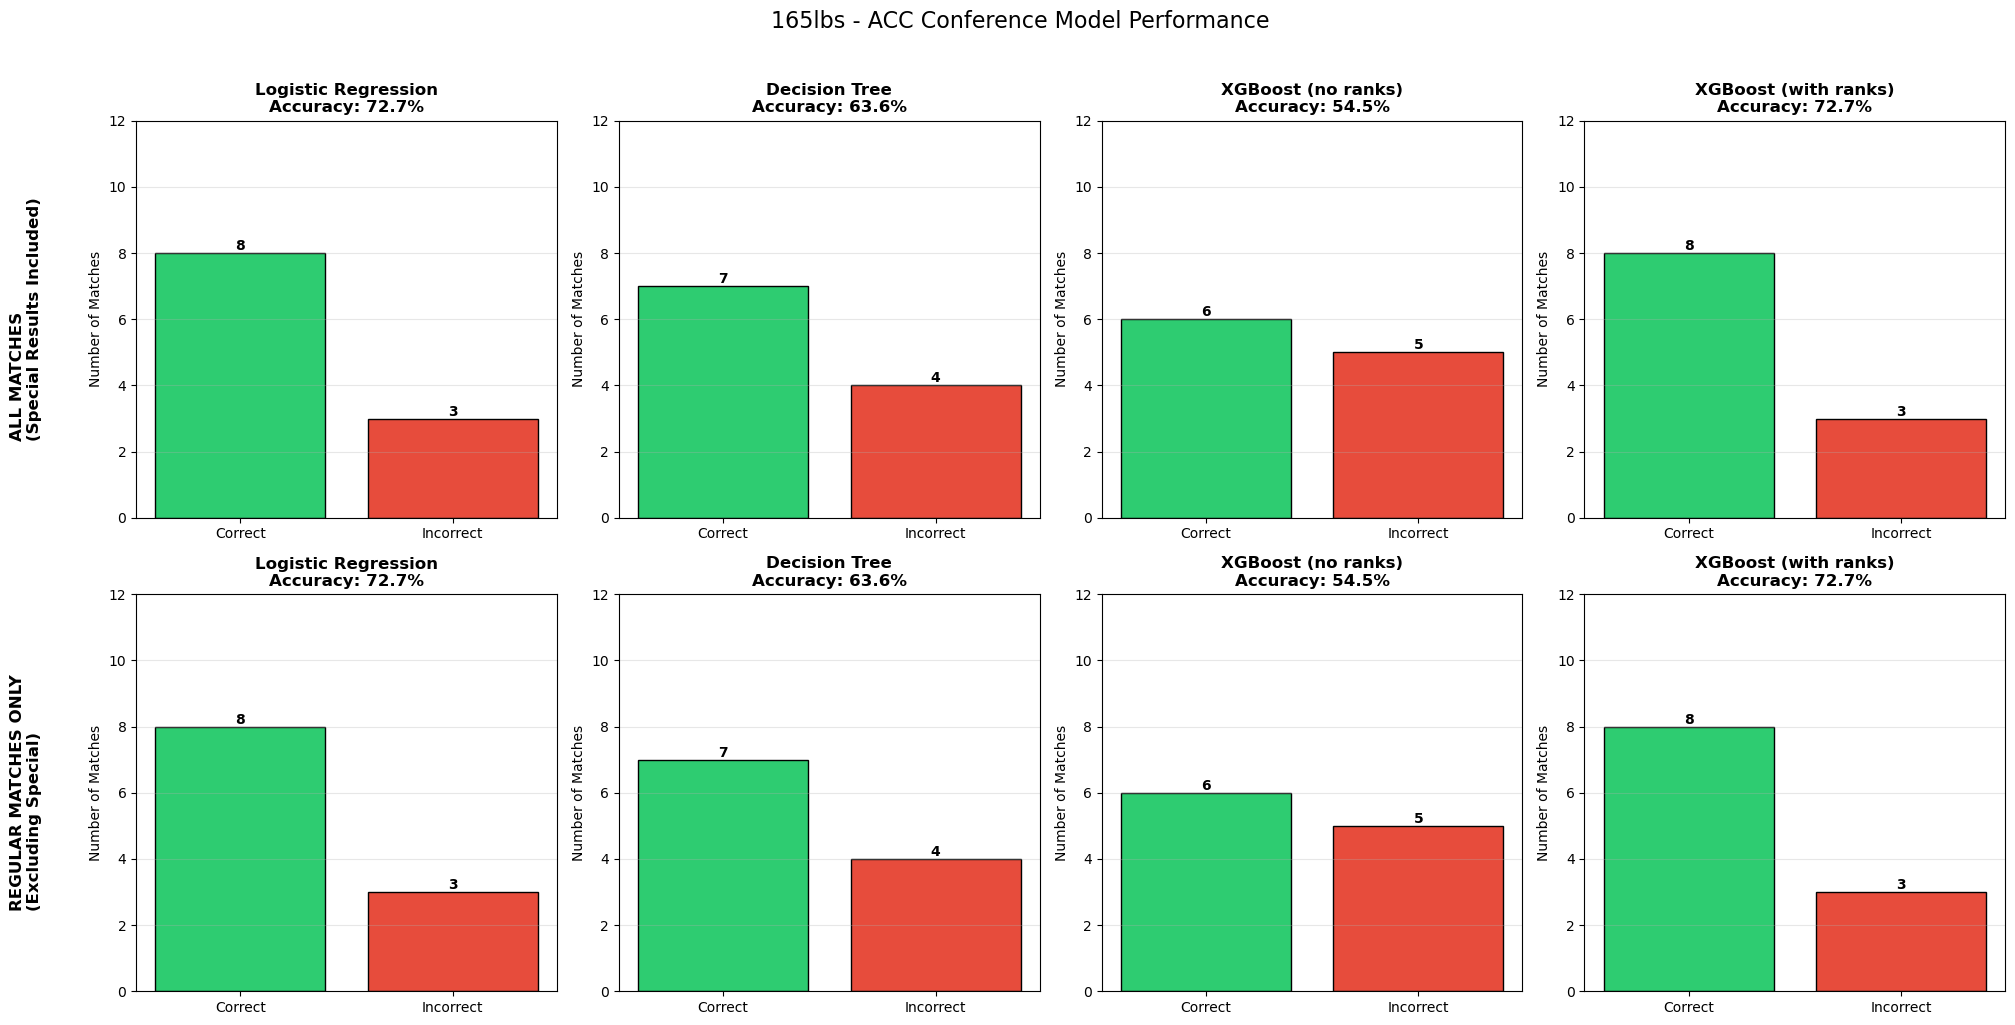


📊 MODEL RANKING - 165lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Decision Tree,63.6%,7/11
3,XGBoost (no ranks),54.5%,6/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,72.7%,8/11
1,XGBoost (with ranks),72.7%,8/11
2,Decision Tree,63.6%,7/11
3,XGBoost (no ranks),54.5%,6/11



📊 SUMMARY STATISTICS - 165lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,165lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,11 (100.0%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),72.7%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 165lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,72.7%,8/11,72.7%,8/11
1,Decision Tree,63.6%,7/11,63.6%,7/11
2,XGBoost (no ranks),54.5%,6/11,54.5%,6/11
3,XGBoost (with ranks),72.7%,8/11,72.7%,8/11



✅ 165lbs evaluation complete and added to overall results

📊 165lbs Quick Results:
   Logistic Regression: 8/11 (72.7%)
   Decision Tree: 7/11 (63.6%)
   XGBoost (no ranks): 6/11 (54.5%)
   XGBoost (with ranks): 8/11 (72.7%)



In [9]:
# ============================================
# 165lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 165lbs ACC TOURNAMENT RESULTS")
print("="*100)

actual_results_165 = {
    # Quarterfinals
    ('Bryce Hepner', 'Jared Keslar', 'Quarterfinal'): 'Bryce Hepner',  # Dec 4-0
    ('Mac Church', 'Michael Murphy', 'Quarterfinal'): 'Mac Church',  # Dec 5-1
    ('EJ Parco', 'Aurelius Dunbar', 'Quarterfinal'): 'EJ Parco',  # MD 9-0
    # Note: Will Denny had a bye - no match to record
    
    # Consolation Round 1
    ('Michael Murphy', 'Aurelius Dunbar', 'Consolation Round 1'): 'Michael Murphy',  # Dec 2-1
    
    # Semifinals
    ('Bryce Hepner', 'Will Denny', 'Semifinal'): 'Bryce Hepner',  # Dec 10-3
    ('Mac Church', 'EJ Parco', 'Semifinal'): 'Mac Church',  # SV-1 4-1
    
    # Consolation Semis
    ('EJ Parco', 'Jared Keslar', 'Consolation Semi'): 'EJ Parco',  # Dec 4-2
    ('Will Denny', 'Michael Murphy', 'Consolation Semi'): 'Will Denny',  # Dec 6-3
    
    # 3rd Place Match
    ('EJ Parco', 'Will Denny', '3rd Place Match'): 'EJ Parco',  # Dec 5-1
    
    # 5th Place Match
    ('Jared Keslar', 'Michael Murphy', '5th Place Match'): 'Jared Keslar',  # MD 11-3
    
    # Championship Final
    ('Bryce Hepner', 'Mac Church', 'Championship'): 'Bryce Hepner',  # Dec 2-0
}

# Track special matches (injury, forfeit, DQ) - none for 165lbs
special_matches_165 = []  # No special matches mentioned

print(f"\n📊 165lbs Results Summary:")
print(f"   Total matches: {len(actual_results_165)}")
print(f"   Special matches: {len(special_matches_165)}")

# Display actual matches
actual_matches_df_165 = []
for (w1, w2, round_name), winner in actual_results_165.items():
    is_special = (w1, w2, round_name) in special_matches_165 or (w2, w1, round_name) in special_matches_165
    actual_matches_df_165.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', '5th Place Match', 'Championship']
actual_matches_df_165 = pd.DataFrame(actual_matches_df_165)
actual_matches_df_165['Round Order'] = actual_matches_df_165['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_165 = actual_matches_df_165.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_165)

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_165.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_165.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings in 165lbs
print("\n🔍 Checking for potential multiple meetings:")
# EJ Parco vs Will Denny - they meet in Consolation Semi and 3rd Place Match? 
# Yes! They wrestle twice:
# - Consolation Semi: EJ Parco beat Will Denny? No, check: 
#   Consolation Semi: EJ Parco vs Jared Keslar, Will Denny vs Michael Murphy
#   So they actually meet in 3rd Place Match only? Let's trace:
#   - Will Denny loses in Semifinal to Bryce Hepner
#   - EJ Parco loses in Semifinal to Mac Church
#   - Both win their Consolation Semis
#   - They meet in 3rd Place Match (only once)
#   So no multiple meetings in this weight class

potential_multiples = [
    ('EJ Parco', 'Will Denny'),
    ('Bryce Hepner', 'Mac Church'),
    ('Jared Keslar', 'Michael Murphy'),
]

for w1, w2 in potential_multiples:
    matches = [(r, win) for (a, b, r), win in actual_results_165.items() 
               if (a == w1 and b == w2) or (a == w2 and b == w1)]
    if len(matches) > 1:
        print(f"✅ Found: {w1} vs {w2} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1} vs {w2} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1} vs {w2} - no matches")

# ============================================
# EVALUATE 165lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 165lbs")
print("="*100)

eval_165, summary_165 = evaluate_weight_class(
    weight_class=165,
    actual_results=actual_results_165,
    special_matches=special_matches_165,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_165:
    all_weight_results.append(summary_165)
    print("\n✅ 165lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 165lbs Quick Results:")
    if 'regular_metrics' in summary_165 and summary_165['regular_metrics']:
        for model, metrics in summary_165['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    else:
        print("   No regular matches to evaluate")
else:
    print("\n⚠️ 165lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 174lbs ACC TOURNAMENT RESULTS

📊 174lbs Results Summary:
   Total matches: 10
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Sergio Desiante,Nick Hamilton,Sergio Desiante,REGULAR
1,Quarterfinal,Collin Carrigan,Aiden Wallace,Collin Carrigan,REGULAR
2,Quarterfinal,Matthew Singleton,Collin Guffey,Matthew Singleton,REGULAR
3,Consolation Round 1,Collin Guffey,Aiden Wallace,Collin Guffey,REGULAR
4,Semifinal,Sergio Desiante,Luca Augustine,Sergio Desiante,REGULAR
5,Semifinal,Matthew Singleton,Collin Carrigan,Matthew Singleton,REGULAR
6,Consolation Semi,Collin Carrigan,Nick Hamilton,Collin Carrigan,REGULAR
7,Consolation Semi,Luca Augustine,Collin Guffey,Luca Augustine,REGULAR
8,3rd Place Match,Collin Carrigan,Luca Augustine,Collin Carrigan,REGULAR
9,Championship,Matthew Singleton,Sergio Desiante,Matthew Singleton,REGULAR



🔍 Verifying wrestler names in predictions dataset:
✅ Aiden Wallace found in predictions
✅ Collin Carrigan found in predictions
✅ Collin Guffey found in predictions
✅ Luca Augustine found in predictions
✅ Matthew Singleton found in predictions
✅ Nick Hamilton found in predictions
✅ Sergio Desiante found in predictions

✅ No multiple meetings detected

🔍 EVALUATING 174lbs

🏋️  EVALUATING 174lbs - ACC CONFERENCE

📊 174lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 174lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Sergio Desiante,Nick Hamilton,1 of 1,Sergio Desiante,❌,68.4%,❌,70.0%,❌,63.5%,✅,68.6%
1,Quarterfinal,Collin Carrigan,Aiden Wallace,1 of 1,Collin Carrigan,❌,77.9%,❌,74.6%,❌,87.5%,❌,64.6%
2,Quarterfinal,Matthew Singleton,Collin Guffey,1 of 1,Matthew Singleton,✅,82.9%,✅,74.6%,✅,91.3%,✅,95.7%
3,Consolation Round 1,Collin Guffey,Aiden Wallace,1 of 1,Collin Guffey,❌,83.3%,❌,74.6%,❌,89.0%,❌,75.1%
4,Semifinal,Sergio Desiante,Luca Augustine,1 of 1,Sergio Desiante,❌,71.4%,❌,70.0%,❌,79.8%,❌,80.6%
5,Semifinal,Matthew Singleton,Collin Carrigan,1 of 1,Matthew Singleton,✅,77.4%,✅,74.6%,✅,89.1%,✅,96.0%
6,Consolation Semi,Collin Carrigan,Nick Hamilton,1 of 1,Collin Carrigan,❌,71.5%,❌,74.6%,❌,83.4%,❌,86.0%
7,Consolation Semi,Luca Augustine,Collin Guffey,1 of 1,Luca Augustine,✅,80.4%,✅,74.6%,✅,91.4%,✅,94.4%
8,3rd Place Match,Collin Carrigan,Luca Augustine,1 of 1,Collin Carrigan,❌,74.3%,❌,74.6%,❌,86.4%,❌,95.6%
9,Championship,Matthew Singleton,Sergio Desiante,1 of 1,Matthew Singleton,✅,74.8%,✅,70.0%,✅,79.0%,✅,85.3%



📊 MODEL ACCURACY METRICS - 174lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,4/10,40.0%
1,Decision Tree,4/10,40.0%
2,XGBoost (no ranks),4/10,40.0%
3,XGBoost (with ranks),5/10,50.0%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,4/10,40.0%
1,Decision Tree,4/10,40.0%
2,XGBoost (no ranks),4/10,40.0%
3,XGBoost (with ranks),5/10,50.0%


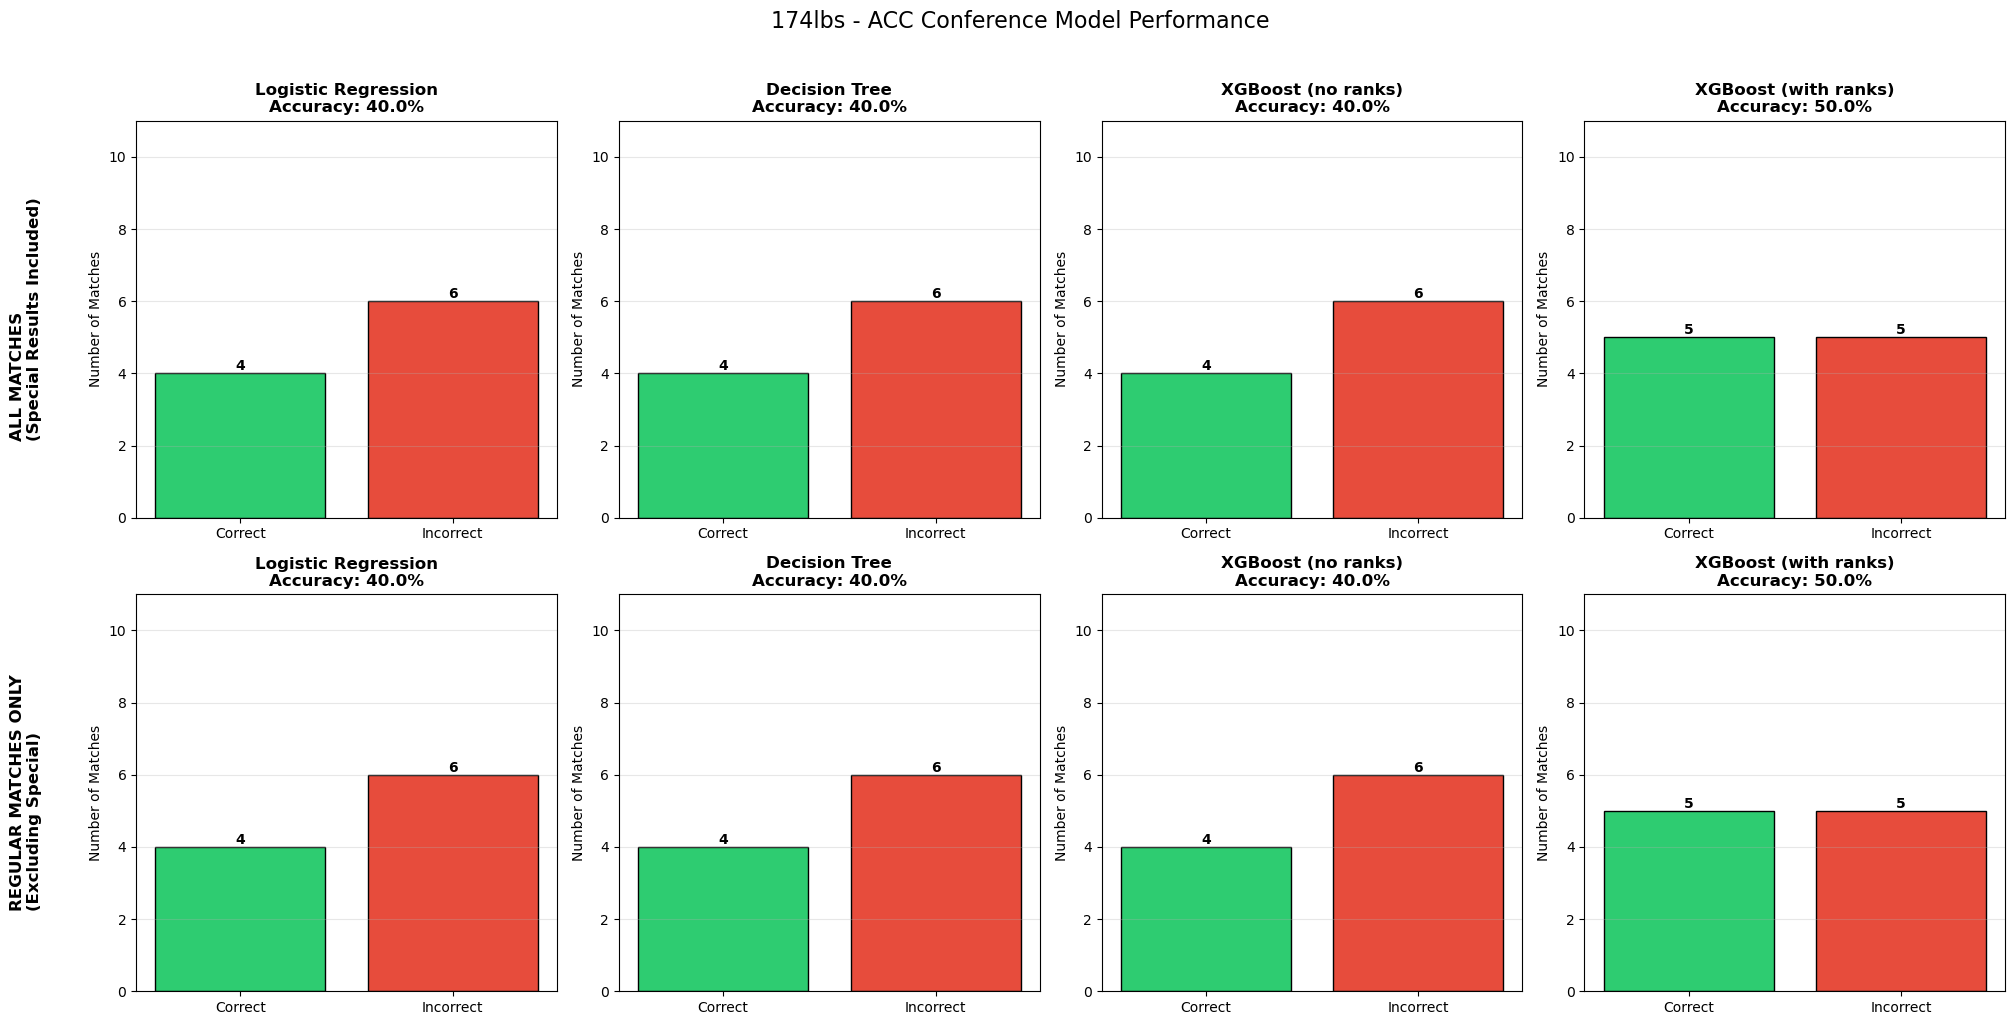


📊 MODEL RANKING - 174lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),50.0%,5/10
1,Logistic Regression,40.0%,4/10
2,Decision Tree,40.0%,4/10
3,XGBoost (no ranks),40.0%,4/10



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),50.0%,5/10
1,Logistic Regression,40.0%,4/10
2,Decision Tree,40.0%,4/10
3,XGBoost (no ranks),40.0%,4/10



📊 SUMMARY STATISTICS - 174lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,174lbs
2,Total Matches Evaluated,10
3,Unique Matchups,10
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,10 (100.0%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),50.0%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 174lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,40.0%,4/10,40.0%,4/10
1,Decision Tree,40.0%,4/10,40.0%,4/10
2,XGBoost (no ranks),40.0%,4/10,40.0%,4/10
3,XGBoost (with ranks),50.0%,5/10,50.0%,5/10



✅ 174lbs evaluation complete and added to overall results

📊 174lbs Quick Results:
   Logistic Regression: 4/10 (40.0%)
   Decision Tree: 4/10 (40.0%)
   XGBoost (no ranks): 4/10 (40.0%)
   XGBoost (with ranks): 5/10 (50.0%)



In [10]:
# ============================================
# 174lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS) - CORRECTED NAMES
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 174lbs ACC TOURNAMENT RESULTS")
print("="*100)

# Using correct names from dataframe:
# - Matthew Singleton instead of Matty Singleton
# - Aiden Wallace instead of Aidan Wallace

actual_results_174 = {
    # Quarterfinals
    ('Sergio Desiante', 'Nick Hamilton', 'Quarterfinal'): 'Sergio Desiante',  # MD 9-1
    ('Collin Carrigan', 'Aiden Wallace', 'Quarterfinal'): 'Collin Carrigan',  # Dec 2-1
    ('Matthew Singleton', 'Collin Guffey', 'Quarterfinal'): 'Matthew Singleton',  # Dec 5-2
    # Note: Luca Augustine had a bye - no match to record
    
    # Consolation Round 1
    ('Collin Guffey', 'Aiden Wallace', 'Consolation Round 1'): 'Collin Guffey',  # SV-1 4-1
    
    # Semifinals
    ('Sergio Desiante', 'Luca Augustine', 'Semifinal'): 'Sergio Desiante',  # Dec 8-3
    ('Matthew Singleton', 'Collin Carrigan', 'Semifinal'): 'Matthew Singleton',  # MD 11-2
    
    # Consolation Semis
    ('Collin Carrigan', 'Nick Hamilton', 'Consolation Semi'): 'Collin Carrigan',  # Dec 4-3
    ('Luca Augustine', 'Collin Guffey', 'Consolation Semi'): 'Luca Augustine',  # Dec 4-1
    
    # 3rd Place Match
    ('Collin Carrigan', 'Luca Augustine', '3rd Place Match'): 'Collin Carrigan',  # Dec 4-3
    
    # Note: No 5th Place Match mentioned for 174lbs
    
    # Championship Final
    ('Matthew Singleton', 'Sergio Desiante', 'Championship'): 'Matthew Singleton',  # TB-1 5-3
}

# Track special matches (injury, forfeit, DQ) - none for 174lbs
special_matches_174 = []  # No special matches mentioned

print(f"\n📊 174lbs Results Summary:")
print(f"   Total matches: {len(actual_results_174)}")
print(f"   Special matches: {len(special_matches_174)}")

# Display actual matches
actual_matches_df_174 = []
for (w1, w2, round_name), winner in actual_results_174.items():
    is_special = (w1, w2, round_name) in special_matches_174 or (w2, w1, round_name) in special_matches_174
    actual_matches_df_174.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', 'Championship']
actual_matches_df_174 = pd.DataFrame(actual_matches_df_174)
actual_matches_df_174['Round Order'] = actual_matches_df_174['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_174 = actual_matches_df_174.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_174)

# Verify all names exist in predictions
print("\n🔍 Verifying wrestler names in predictions dataset:")
wrestlers_174 = set()
for (w1, w2, _) in actual_results_174.keys():
    wrestlers_174.add(w1)
    wrestlers_174.add(w2)

preds_174 = acc_preds[acc_preds['weight_class'] == 174]
all_pred_wrestlers = set(preds_174['wrestler1'].tolist() + preds_174['wrestler2'].tolist())

missing_wrestlers = []
for wrestler in sorted(wrestlers_174):
    if wrestler in all_pred_wrestlers:
        print(f"✅ {wrestler} found in predictions")
    else:
        print(f"❌ {wrestler} NOT found in predictions")
        missing_wrestlers.append(wrestler)

if missing_wrestlers:
    print(f"\n⚠️ Missing wrestlers: {missing_wrestlers}")
    print("   Please check exact spelling in the CSV file")
    
    # Show available wrestlers in this weight class for reference
    print("\n📋 Available wrestlers in 174lbs predictions:")
    available = sorted(set(preds_174['wrestler1'].tolist() + preds_174['wrestler2'].tolist()))
    for w in available:
        print(f"   - {w}")

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_174.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_174.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# ============================================
# EVALUATE 174lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 174lbs")
print("="*100)

eval_174, summary_174 = evaluate_weight_class(
    weight_class=174,
    actual_results=actual_results_174,
    special_matches=special_matches_174,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_174:
    all_weight_results.append(summary_174)
    print("\n✅ 174lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 174lbs Quick Results:")
    if 'regular_metrics' in summary_174 and summary_174['regular_metrics']:
        for model, metrics in summary_174['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    else:
        print("   No regular matches to evaluate")
else:
    print("\n⚠️ 174lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 184lbs ACC TOURNAMENT RESULTS

📊 184lbs Results Summary:
   Total matches: 11
   Special matches: 3


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Jake Dailey,Donald Cates,Jake Dailey,SPECIAL
1,Quarterfinal,Jaden Bullock,Griffin Gammell,Jaden Bullock,REGULAR
2,Quarterfinal,Abe Wojcikiewicz,David Hussey,Abe Wojcikiewicz,REGULAR
3,Consolation Round 1,Griffin Gammell,David Hussey,Griffin Gammell,REGULAR
4,Semifinal,Jake Dailey,Chase Kranitz,Jake Dailey,REGULAR
5,Semifinal,Jaden Bullock,Abe Wojcikiewicz,Jaden Bullock,REGULAR
6,Consolation Semi,Abe Wojcikiewicz,Donald Cates,Abe Wojcikiewicz,SPECIAL
7,Consolation Semi,Chase Kranitz,Griffin Gammell,Chase Kranitz,REGULAR
8,3rd Place Match,Abe Wojcikiewicz,Chase Kranitz,Abe Wojcikiewicz,REGULAR
9,5th Place Match,Griffin Gammell,Donald Cates,Griffin Gammell,SPECIAL



🔍 Verifying wrestler names in predictions dataset:
✅ Abe Wojcikiewicz found in predictions
✅ Chase Kranitz found in predictions
✅ David Hussey found in predictions
✅ Donald Cates found in predictions
✅ Griffin Gammell found in predictions
✅ Jaden Bullock found in predictions
✅ Jake Dailey found in predictions

✅ All wrestlers found in predictions!

✅ No multiple meetings detected

🔍 EVALUATING 184lbs

🏋️  EVALUATING 184lbs - ACC CONFERENCE

📊 184lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 184lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Jake Dailey,Donald Cates,1 of 1,Jake Dailey,✅,78.0%,✅,89.0%,✅,79.9%,✅,64.7%
1,Quarterfinal,Jaden Bullock,Griffin Gammell,1 of 1,Jaden Bullock,✅,61.7%,✅,74.6%,✅,72.0%,✅,90.7%
2,Quarterfinal,Abe Wojcikiewicz,David Hussey,1 of 1,Abe Wojcikiewicz,✅,73.8%,✅,89.0%,✅,86.7%,✅,95.9%
3,Consolation Round 1,Griffin Gammell,David Hussey,1 of 1,Griffin Gammell,✅,61.9%,✅,74.6%,✅,60.4%,✅,85.9%
4,Semifinal,Jake Dailey,Chase Kranitz,1 of 1,Jake Dailey,✅,63.1%,✅,74.6%,✅,67.3%,❌,63.7%
5,Semifinal,Jaden Bullock,Abe Wojcikiewicz,1 of 1,Jaden Bullock,❌,51.8%,❌,53.1%,✅,51.4%,✅,72.1%
6,Consolation Semi,Abe Wojcikiewicz,Donald Cates,1 of 1,Abe Wojcikiewicz,✅,61.2%,✅,74.6%,✅,66.4%,✅,50.7%
7,Consolation Semi,Chase Kranitz,Griffin Gammell,1 of 1,Chase Kranitz,✅,69.8%,✅,74.6%,✅,83.4%,✅,93.7%
8,3rd Place Match,Abe Wojcikiewicz,Chase Kranitz,1 of 1,Abe Wojcikiewicz,❌,57.2%,❌,61.1%,❌,61.4%,✅,55.8%
9,5th Place Match,Griffin Gammell,Donald Cates,1 of 1,Griffin Gammell,❌,52.3%,❌,74.7%,❌,60.7%,❌,86.8%



📊 MODEL ACCURACY METRICS - 184lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,7/11,63.6%
1,Decision Tree,7/11,63.6%
2,XGBoost (no ranks),8/11,72.7%
3,XGBoost (with ranks),9/11,81.8%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,5/8,62.5%
1,Decision Tree,5/8,62.5%
2,XGBoost (no ranks),6/8,75.0%
3,XGBoost (with ranks),7/8,87.5%


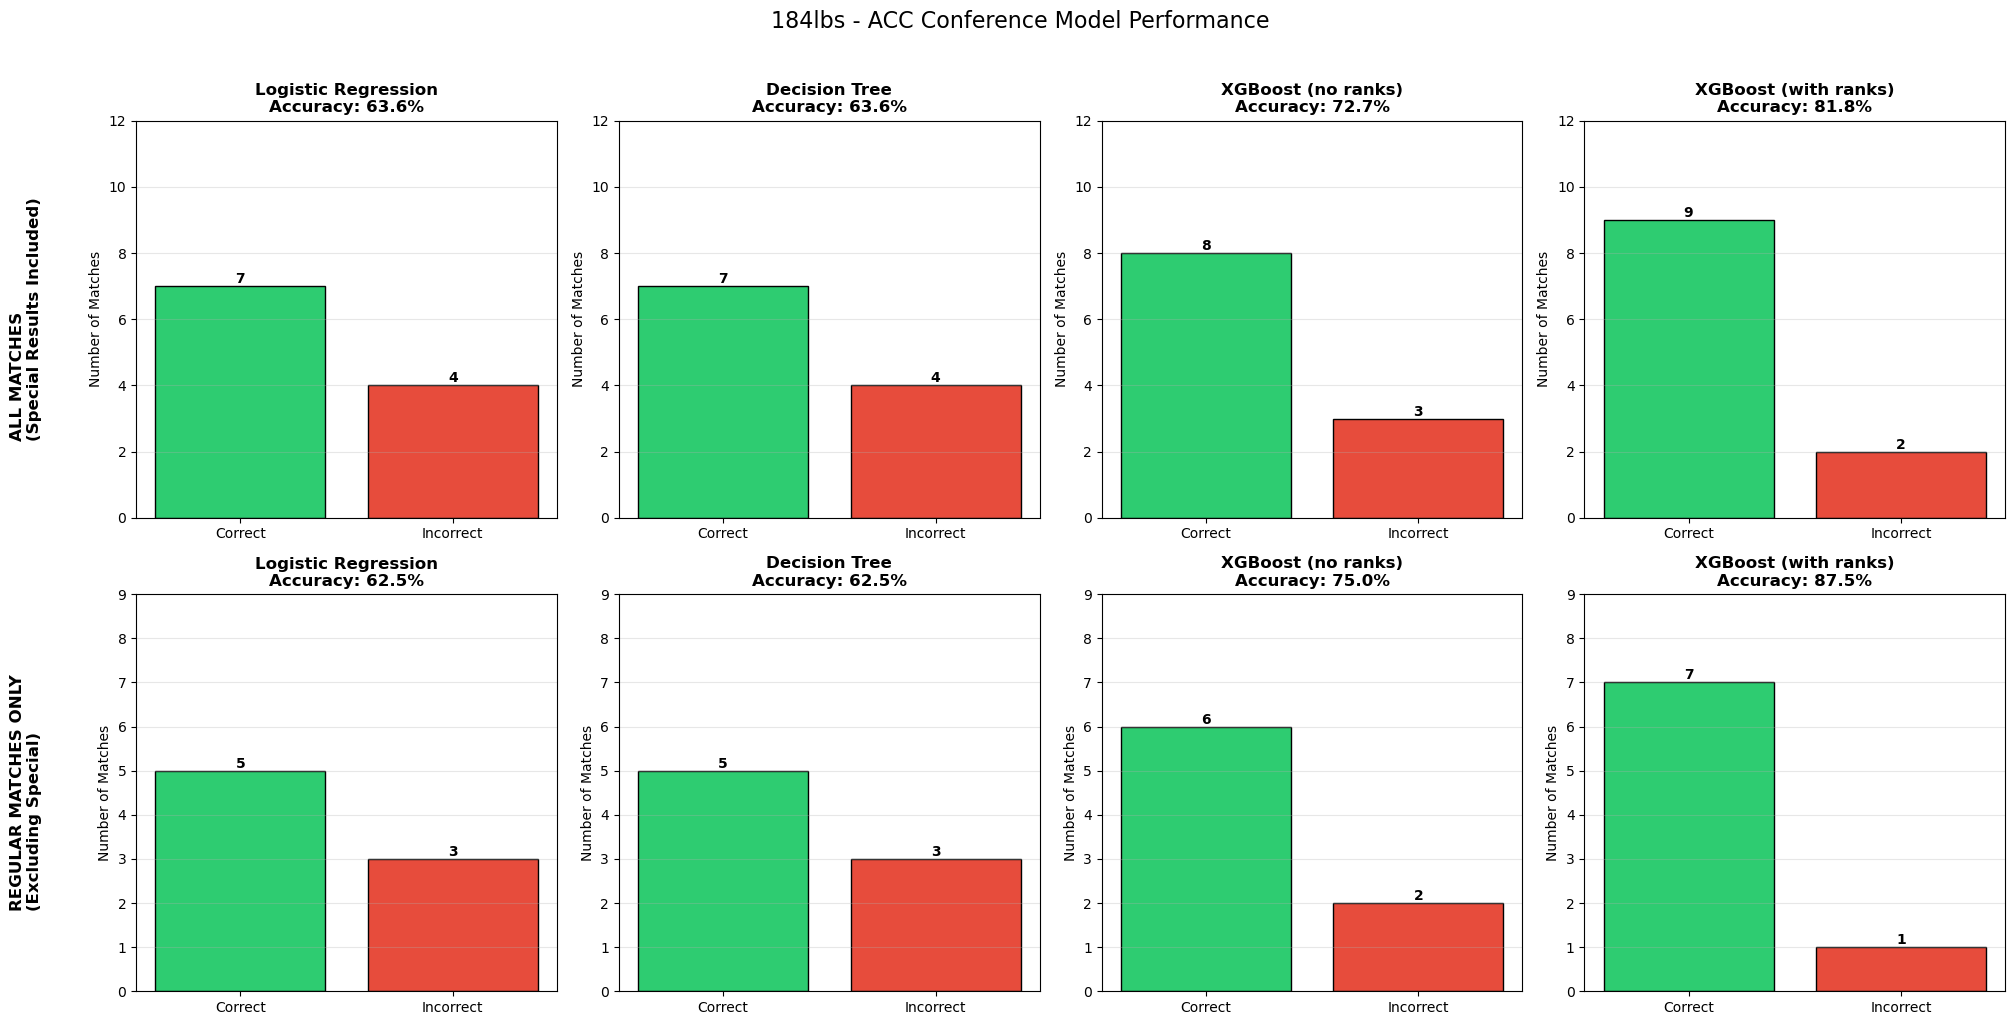


📊 MODEL RANKING - 184lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),81.8%,9/11
1,XGBoost (no ranks),72.7%,8/11
2,Logistic Regression,63.6%,7/11
3,Decision Tree,63.6%,7/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),87.5%,7/8
1,XGBoost (no ranks),75.0%,6/8
2,Logistic Regression,62.5%,5/8
3,Decision Tree,62.5%,5/8



📊 SUMMARY STATISTICS - 184lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,184lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,3 (27.3%)
6,Regular Matches,8 (72.7%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),81.8%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 184lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,63.6%,7/11,62.5%,5/8
1,Decision Tree,63.6%,7/11,62.5%,5/8
2,XGBoost (no ranks),72.7%,8/11,75.0%,6/8
3,XGBoost (with ranks),81.8%,9/11,87.5%,7/8



✅ 184lbs evaluation complete and added to overall results

📊 184lbs Quick Results:
   Logistic Regression: 5/8 (62.5%)
   Decision Tree: 5/8 (62.5%)
   XGBoost (no ranks): 6/8 (75.0%)
   XGBoost (with ranks): 7/8 (87.5%)

⚠️ Special matches in this weight class: 3
   - Quarterfinal: Jake Dailey vs Donald Cates
   - Consolation Semi: Abe Wojcikiewicz vs Donald Cates
   - 5th Place Match: Griffin Gammell vs Donald Cates



In [11]:
# ============================================
# 184lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS) - CORRECTED NAMES
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 184lbs ACC TOURNAMENT RESULTS")
print("="*100)

# Using correct names from dataframe verification:
# - Abe Wojcikiewicz instead of Abraham Wojcikiewicz
# - Donald Cates instead of Don Cates
# - Others remain the same

actual_results_184 = {
    # Quarterfinals
    ('Jake Dailey', 'Donald Cates', 'Quarterfinal'): 'Jake Dailey',  # DQ
    ('Jaden Bullock', 'Griffin Gammell', 'Quarterfinal'): 'Jaden Bullock',  # Dec 2-1
    ('Abe Wojcikiewicz', 'David Hussey', 'Quarterfinal'): 'Abe Wojcikiewicz',  # MD 9-0
    # Note: Chase Kranitz had a bye - no match to record
    
    # Consolation Round 1
    ('Griffin Gammell', 'David Hussey', 'Consolation Round 1'): 'Griffin Gammell',  # Dec 7-5
    
    # Semifinals
    ('Jake Dailey', 'Chase Kranitz', 'Semifinal'): 'Jake Dailey',  # Dec 9-2
    ('Jaden Bullock', 'Abe Wojcikiewicz', 'Semifinal'): 'Jaden Bullock',  # MD 11-2
    
    # Consolation Semis
    ('Abe Wojcikiewicz', 'Donald Cates', 'Consolation Semi'): 'Abe Wojcikiewicz',  # Forfeit
    ('Chase Kranitz', 'Griffin Gammell', 'Consolation Semi'): 'Chase Kranitz',  # Dec 4-3
    
    # 3rd Place Match
    ('Abe Wojcikiewicz', 'Chase Kranitz', '3rd Place Match'): 'Abe Wojcikiewicz',  # Fall 4:41
    
    # 5th Place Match
    ('Griffin Gammell', 'Donald Cates', '5th Place Match'): 'Griffin Gammell',  # Forfeit
    
    # Championship Final
    ('Jaden Bullock', 'Jake Dailey', 'Championship'): 'Jaden Bullock',  # SV-1 4-1
}

# Track special matches (injury, forfeit, DQ)
special_matches_184 = [
    ('Jake Dailey', 'Donald Cates', 'Quarterfinal'),  # DQ
    ('Abe Wojcikiewicz', 'Donald Cates', 'Consolation Semi'),  # Forfeit
    ('Griffin Gammell', 'Donald Cates', '5th Place Match'),  # Forfeit
]

print(f"\n📊 184lbs Results Summary:")
print(f"   Total matches: {len(actual_results_184)}")
print(f"   Special matches: {len(special_matches_184)}")

# Display actual matches
actual_matches_df_184 = []
for (w1, w2, round_name), winner in actual_results_184.items():
    is_special = (w1, w2, round_name) in special_matches_184 or (w2, w1, round_name) in special_matches_184
    actual_matches_df_184.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', '5th Place Match', 'Championship']
actual_matches_df_184 = pd.DataFrame(actual_matches_df_184)
actual_matches_df_184['Round Order'] = actual_matches_df_184['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_184 = actual_matches_df_184.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_184)

# Verify all names exist in predictions
print("\n🔍 Verifying wrestler names in predictions dataset:")
wrestlers_184 = set()
for (w1, w2, _) in actual_results_184.keys():
    wrestlers_184.add(w1)
    wrestlers_184.add(w2)

preds_184 = acc_preds[acc_preds['weight_class'] == 184]
all_pred_wrestlers = set(preds_184['wrestler1'].tolist() + preds_184['wrestler2'].tolist())

missing_wrestlers = []
for wrestler in sorted(wrestlers_184):
    if wrestler in all_pred_wrestlers:
        print(f"✅ {wrestler} found in predictions")
    else:
        print(f"❌ {wrestler} NOT found in predictions")
        missing_wrestlers.append(wrestler)

if missing_wrestlers:
    print(f"\n⚠️ Missing wrestlers: {missing_wrestlers}")
    
    # Show available wrestlers in this weight class for reference
    print("\n📋 Available wrestlers in 184lbs predictions:")
    available = sorted(set(preds_184['wrestler1'].tolist() + preds_184['wrestler2'].tolist()))
    for w in available:
        print(f"   - {w}")
else:
    print("\n✅ All wrestlers found in predictions!")

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_184.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_184.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# ============================================
# EVALUATE 184lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 184lbs")
print("="*100)

eval_184, summary_184 = evaluate_weight_class(
    weight_class=184,
    actual_results=actual_results_184,
    special_matches=special_matches_184,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_184:
    all_weight_results.append(summary_184)
    print("\n✅ 184lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 184lbs Quick Results:")
    if 'regular_metrics' in summary_184 and summary_184['regular_metrics']:
        for model, metrics in summary_184['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
    
    # Show special matches info
    print(f"\n⚠️ Special matches in this weight class: {len(special_matches_184)}")
    for (w1, w2, round_name) in special_matches_184:
        print(f"   - {round_name}: {w1} vs {w2}")
else:
    print("\n⚠️ 184lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 197lbs ACC TOURNAMENT RESULTS

📊 197lbs Results Summary:
   Total matches: 10
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Robert Platt,Patrick Brophy,Robert Platt,REGULAR
1,Quarterfinal,Sonny Sasso,Steven Burrell Jr.,Sonny Sasso,REGULAR
2,Quarterfinal,Mac Stout,Owen McGrory,Mac Stout,REGULAR
3,Consolation Round 1,Steven Burrell Jr.,Owen McGrory,Steven Burrell Jr.,REGULAR
4,Semifinal,Angelo Posada,Robert Platt,Angelo Posada,REGULAR
5,Semifinal,Sonny Sasso,Mac Stout,Sonny Sasso,REGULAR
6,Consolation Semi,Mac Stout,Patrick Brophy,Mac Stout,REGULAR
7,Consolation Semi,Robert Platt,Steven Burrell Jr.,Robert Platt,REGULAR
8,3rd Place Match,Mac Stout,Robert Platt,Mac Stout,REGULAR
9,Championship,Sonny Sasso,Angelo Posada,Sonny Sasso,REGULAR



🔍 Verifying wrestler names in predictions dataset:
✅ Angelo Posada found in predictions
✅ Mac Stout found in predictions
✅ Owen McGrory found in predictions
✅ Patrick Brophy found in predictions
✅ Robert Platt found in predictions
✅ Sonny Sasso found in predictions
⚠️ Steven Burrell Jr. not found, but Steven Burrell is available

✅ All wrestlers found in predictions!

🔄 Updating results with correct names from predictions...

✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Mac Stout vs Robert Platt - 1 match (3rd Place Match)
ℹ️ Sonny Sasso vs Mac Stout - 1 match (Semifinal)
ℹ️ Angelo Posada vs Robert Platt - 1 match (Semifinal)
ℹ️ Robert Platt vs Steven Burrell - 1 match (Consolation Semi)

🔍 EVALUATING 197lbs

🏋️  EVALUATING 197lbs - ACC CONFERENCE

📊 197lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 197lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Robert Platt,Patrick Brophy,1 of 1,Robert Platt,❌,57.6%,❌,61.1%,❌,64.4%,❌,83.6%
1,Quarterfinal,Sonny Sasso,Steven Burrell,1 of 1,Sonny Sasso,✅,64.7%,✅,74.6%,✅,75.8%,✅,87.0%
2,Quarterfinal,Mac Stout,Owen McGrory,1 of 1,Mac Stout,✅,81.5%,✅,89.0%,✅,91.3%,✅,96.9%
3,Consolation Round 1,Steven Burrell,Owen McGrory,1 of 1,Steven Burrell,✅,73.2%,✅,74.6%,✅,84.2%,✅,96.2%
4,Semifinal,Angelo Posada,Robert Platt,1 of 1,Angelo Posada,✅,67.6%,✅,74.6%,✅,77.9%,✅,88.5%
5,Semifinal,Sonny Sasso,Mac Stout,1 of 1,Sonny Sasso,✅,53.4%,❌,53.1%,✅,56.0%,✅,72.1%
6,Consolation Semi,Mac Stout,Patrick Brophy,1 of 1,Mac Stout,✅,59.1%,✅,61.1%,✅,71.0%,❌,52.5%
7,Consolation Semi,Robert Platt,Steven Burrell,1 of 1,Robert Platt,❌,54.2%,✅,61.1%,✅,67.9%,✅,72.8%
8,3rd Place Match,Mac Stout,Robert Platt,1 of 1,Mac Stout,✅,66.0%,✅,74.6%,✅,78.6%,✅,86.4%
9,Championship,Sonny Sasso,Angelo Posada,1 of 1,Sonny Sasso,✅,51.6%,✅,61.1%,✅,65.4%,❌,52.9%



📊 MODEL ACCURACY METRICS - 197lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,8/10,80.0%
1,Decision Tree,8/10,80.0%
2,XGBoost (no ranks),9/10,90.0%
3,XGBoost (with ranks),7/10,70.0%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,8/10,80.0%
1,Decision Tree,8/10,80.0%
2,XGBoost (no ranks),9/10,90.0%
3,XGBoost (with ranks),7/10,70.0%


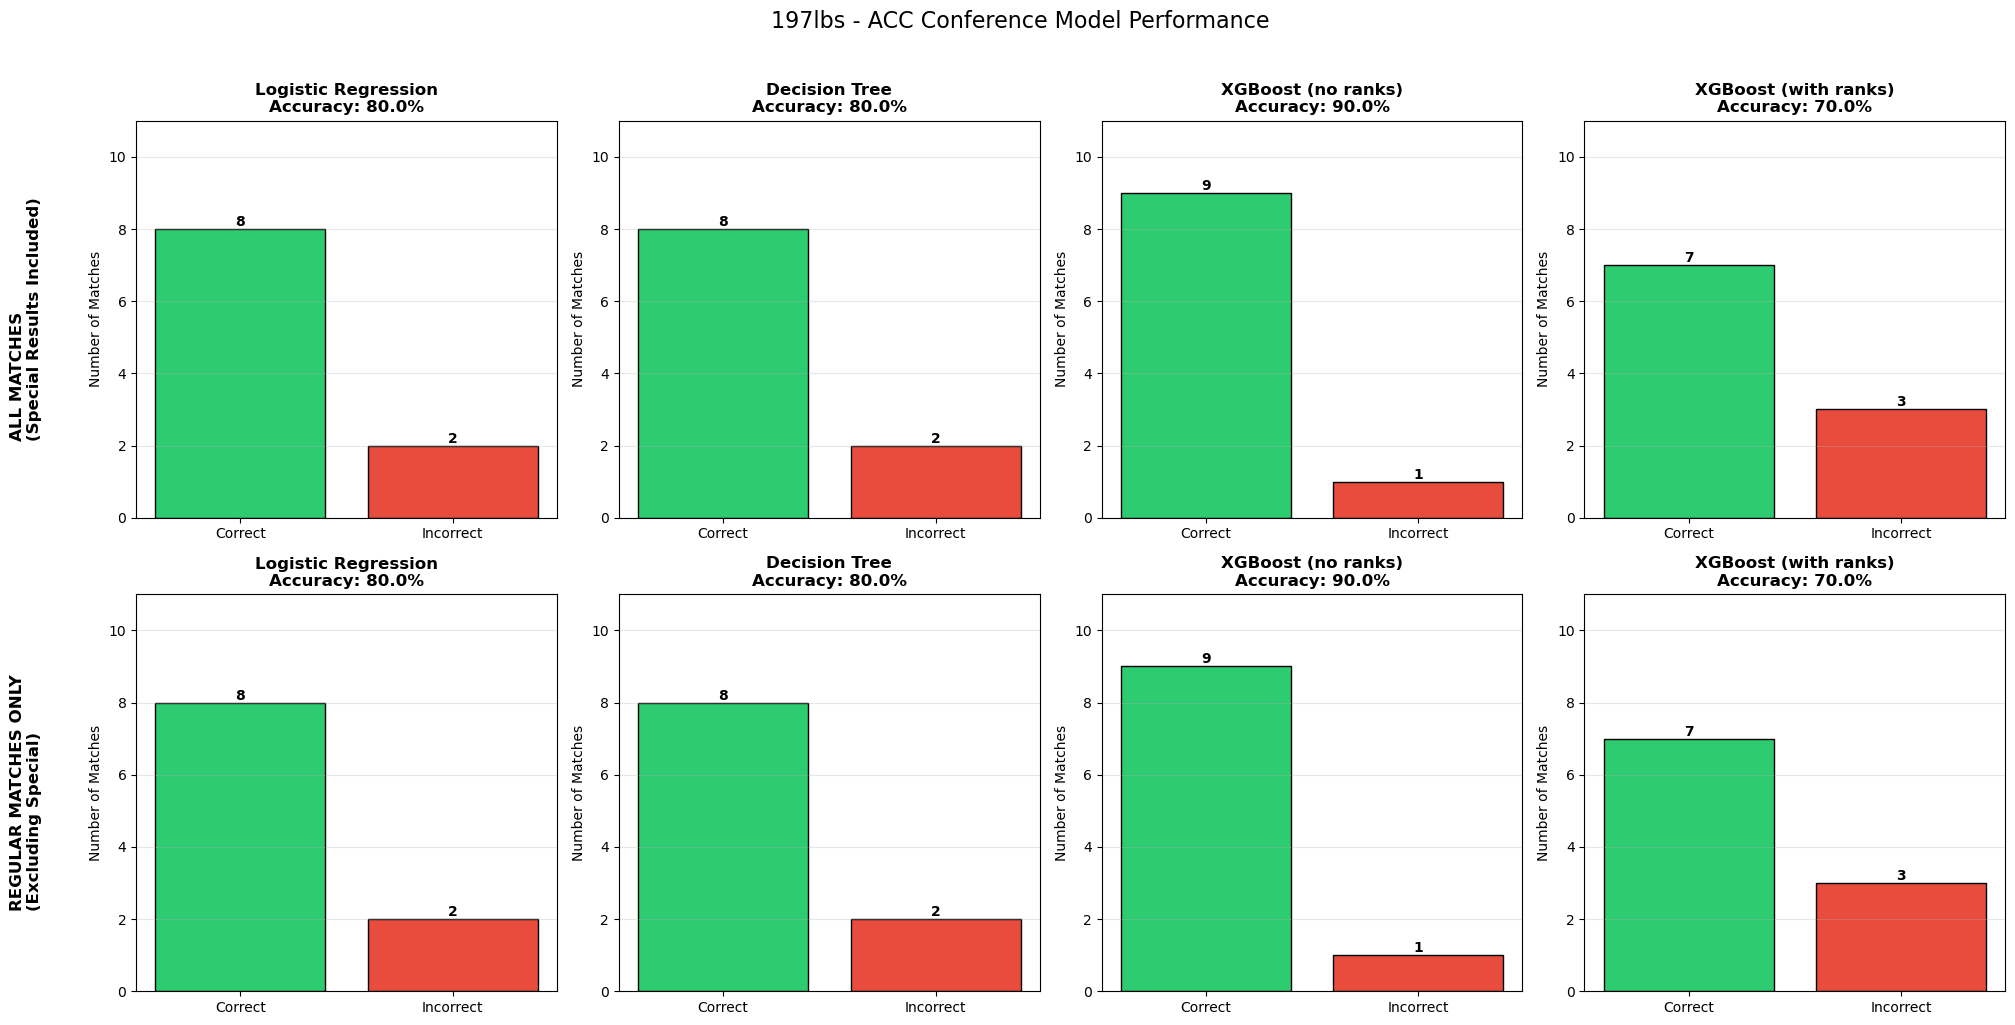


📊 MODEL RANKING - 197lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (no ranks),90.0%,9/10
1,Logistic Regression,80.0%,8/10
2,Decision Tree,80.0%,8/10
3,XGBoost (with ranks),70.0%,7/10



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (no ranks),90.0%,9/10
1,Logistic Regression,80.0%,8/10
2,Decision Tree,80.0%,8/10
3,XGBoost (with ranks),70.0%,7/10



📊 SUMMARY STATISTICS - 197lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,197lbs
2,Total Matches Evaluated,10
3,Unique Matchups,10
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,10 (100.0%)
7,Best Model (All Matches),XGBoost (no ranks)
8,Best Model Accuracy (All Matches),90.0%
9,Best Model (Regular Only),XGBoost (no ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 197lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,80.0%,8/10,80.0%,8/10
1,Decision Tree,80.0%,8/10,80.0%,8/10
2,XGBoost (no ranks),90.0%,9/10,90.0%,9/10
3,XGBoost (with ranks),70.0%,7/10,70.0%,7/10



✅ 197lbs evaluation complete and added to overall results

📊 197lbs Quick Results:
   Logistic Regression: 8/10 (80.0%)
   Decision Tree: 8/10 (80.0%)
   XGBoost (no ranks): 9/10 (90.0%)
   XGBoost (with ranks): 7/10 (70.0%)



In [12]:
# ============================================
# 197lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 197lbs ACC TOURNAMENT RESULTS")
print("="*100)

# Using correct names from dataframe
# - Steven Burrell Jr. (might be "Steven Burrell" in your data)
# - Others should match

actual_results_197 = {
    # Quarterfinals
    ('Robert Platt', 'Patrick Brophy', 'Quarterfinal'): 'Robert Platt',  # MD 14-5
    ('Sonny Sasso', 'Steven Burrell Jr.', 'Quarterfinal'): 'Sonny Sasso',  # Fall 4:16
    ('Mac Stout', 'Owen McGrory', 'Quarterfinal'): 'Mac Stout',  # TF-1.5 21-4
    # Note: Angelo Posada had a bye - no match to record
    
    # Consolation Round 1
    ('Steven Burrell Jr.', 'Owen McGrory', 'Consolation Round 1'): 'Steven Burrell Jr.',  # Fall 3:41
    
    # Semifinals
    ('Angelo Posada', 'Robert Platt', 'Semifinal'): 'Angelo Posada',  # Dec 8-5
    ('Sonny Sasso', 'Mac Stout', 'Semifinal'): 'Sonny Sasso',  # SV-1 4-1
    
    # Consolation Semis
    ('Mac Stout', 'Patrick Brophy', 'Consolation Semi'): 'Mac Stout',  # Dec 9-6
    ('Robert Platt', 'Steven Burrell Jr.', 'Consolation Semi'): 'Robert Platt',  # Dec 11-5
    
    # 3rd Place Match
    ('Mac Stout', 'Robert Platt', '3rd Place Match'): 'Mac Stout',  # Dec 5-2
    
    # Note: No 5th Place Match mentioned for 197lbs
    
    # Championship Final
    ('Sonny Sasso', 'Angelo Posada', 'Championship'): 'Sonny Sasso',  # MD 12-2
}

# Track special matches (injury, forfeit, DQ) - none for 197lbs
special_matches_197 = []  # No special matches mentioned

print(f"\n📊 197lbs Results Summary:")
print(f"   Total matches: {len(actual_results_197)}")
print(f"   Special matches: {len(special_matches_197)}")

# Display actual matches
actual_matches_df_197 = []
for (w1, w2, round_name), winner in actual_results_197.items():
    is_special = (w1, w2, round_name) in special_matches_197 or (w2, w1, round_name) in special_matches_197
    actual_matches_df_197.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', 'Championship']
actual_matches_df_197 = pd.DataFrame(actual_matches_df_197)
actual_matches_df_197['Round Order'] = actual_matches_df_197['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_197 = actual_matches_df_197.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_197)

# Verify all names exist in predictions
print("\n🔍 Verifying wrestler names in predictions dataset:")
wrestlers_197 = set()
for (w1, w2, _) in actual_results_197.keys():
    wrestlers_197.add(w1)
    wrestlers_197.add(w2)

preds_197 = acc_preds[acc_preds['weight_class'] == 197]
all_pred_wrestlers = set(preds_197['wrestler1'].tolist() + preds_197['wrestler2'].tolist())

# Common name variations to check
name_variations = {
    'Steven Burrell Jr.': ['Steven Burrell Jr.', 'Steven Burrell', 'Burrell'],
}

missing_wrestlers = []
name_mapping = {}  # To track any needed renames

for wrestler in sorted(wrestlers_197):
    if wrestler in all_pred_wrestlers:
        print(f"✅ {wrestler} found in predictions")
    else:
        # Check for common variations
        found_variation = False
        if wrestler in name_variations:
            for variation in name_variations[wrestler]:
                if variation in all_pred_wrestlers:
                    print(f"⚠️ {wrestler} not found, but {variation} is available")
                    name_mapping[wrestler] = variation
                    found_variation = True
                    break
        
        if not found_variation:
            print(f"❌ {wrestler} NOT found in predictions")
            missing_wrestlers.append(wrestler)

if missing_wrestlers:
    print(f"\n⚠️ Missing wrestlers: {missing_wrestlers}")
    
    # Show available wrestlers in this weight class for reference
    print("\n📋 Available wrestlers in 197lbs predictions:")
    available = sorted(set(preds_197['wrestler1'].tolist() + preds_197['wrestler2'].tolist()))
    for w in available:
        print(f"   - {w}")
else:
    print("\n✅ All wrestlers found in predictions!")

# If we have name mappings, update the actual_results with correct names
if name_mapping:
    print("\n🔄 Updating results with correct names from predictions...")
    updated_results = {}
    for (w1, w2, round_name), winner in actual_results_197.items():
        new_w1 = name_mapping.get(w1, w1)
        new_w2 = name_mapping.get(w2, w2)
        new_winner = name_mapping.get(winner, winner)
        updated_results[(new_w1, new_w2, round_name)] = new_winner
    
    actual_results_197 = updated_results
    
    # Also update special matches if any
    updated_special = []
    for match in special_matches_197:
        if len(match) == 3:
            w1, w2, round_name = match
            new_w1 = name_mapping.get(w1, w1)
            new_w2 = name_mapping.get(w2, w2)
            updated_special.append((new_w1, new_w2, round_name))
    special_matches_197 = updated_special

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_197.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_197.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings in 197lbs
print("\n🔍 Checking for potential multiple meetings:")
# Mac Stout vs Robert Platt - they meet in 3rd Place Match only
# Angelo Posada vs Robert Platt - they meet in Semifinal only
# Sonny Sasso vs Mac Stout - they meet in Semifinal only
# No multiple meetings in this weight class

potential_multiples = [
    ('Mac Stout', 'Robert Platt'),
    ('Sonny Sasso', 'Mac Stout'),
    ('Angelo Posada', 'Robert Platt'),
    ('Robert Platt', 'Steven Burrell Jr.'),
]

for w1, w2 in potential_multiples:
    # Use mapped names if available
    w1_mapped = name_mapping.get(w1, w1)
    w2_mapped = name_mapping.get(w2, w2)
    
    matches = [(r, win) for (a, b, r), win in actual_results_197.items() 
               if (a == w1_mapped and b == w2_mapped) or (a == w2_mapped and b == w1_mapped)]
    if len(matches) > 1:
        print(f"✅ Found: {w1_mapped} vs {w2_mapped} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1_mapped} vs {w2_mapped} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1_mapped} vs {w2_mapped} - no matches")

# ============================================
# EVALUATE 197lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 197lbs")
print("="*100)

eval_197, summary_197 = evaluate_weight_class(
    weight_class=197,
    actual_results=actual_results_197,
    special_matches=special_matches_197,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_197:
    all_weight_results.append(summary_197)
    print("\n✅ 197lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 197lbs Quick Results:")
    if 'regular_metrics' in summary_197 and summary_197['regular_metrics']:
        for model, metrics in summary_197['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 197lbs evaluation failed")

print("\n" + "="*100)


📋 SETTING UP 285lbs ACC TOURNAMENT RESULTS

📊 285lbs Results Summary:
   Total matches: 11
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Quarterfinal,Brenan Morgan,Connor Barket,Brenan Morgan,REGULAR
1,Quarterfinal,Jimmy Mullen,Jacob Levy,Jimmy Mullen,REGULAR
2,Quarterfinal,Dayton Pitzer,Luke Duthie,Dayton Pitzer,REGULAR
3,Consolation Round 1,Luke Duthie,Jacob Levy,Luke Duthie,REGULAR
4,Semifinal,Isaac Trumble,Brenan Morgan,Isaac Trumble,REGULAR
5,Semifinal,Dayton Pitzer,Jimmy Mullen,Dayton Pitzer,REGULAR
6,Consolation Semi,Jimmy Mullen,Connor Barket,Jimmy Mullen,REGULAR
7,Consolation Semi,Brenan Morgan,Luke Duthie,Brenan Morgan,REGULAR
8,3rd Place Match,Jimmy Mullen,Brenan Morgan,Jimmy Mullen,REGULAR
9,5th Place Match,Connor Barket,Luke Duthie,Connor Barket,REGULAR



🔍 Verifying wrestler names in predictions dataset:
✅ Brenan Morgan found in predictions
✅ Connor Barket found in predictions
✅ Dayton Pitzer found in predictions
✅ Isaac Trumble found in predictions
✅ Jacob Levy found in predictions
⚠️ Jimmy Mullen not found, but Jim Mullen is available
✅ Luke Duthie found in predictions

✅ All wrestlers found in predictions!

🔄 Updating results with correct names from predictions...

✅ No multiple meetings detected

🔍 Checking for potential multiple meetings:
ℹ️ Brenan Morgan vs Connor Barket - 1 match (Quarterfinal)
ℹ️ Jim Mullen vs Jacob Levy - 1 match (Quarterfinal)
ℹ️ Dayton Pitzer vs Luke Duthie - 1 match (Quarterfinal)
ℹ️ Jim Mullen vs Brenan Morgan - 1 match (3rd Place Match)
ℹ️ Isaac Trumble vs Dayton Pitzer - 1 match (Championship)

🔍 EVALUATING 285lbs

🏋️  EVALUATING 285lbs - ACC CONFERENCE

📊 285lbs predictions in dataset: 21 matchups

📊 DETAILED EVALUATION - 285lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Quarterfinal,Brenan Morgan,Connor Barket,1 of 1,Brenan Morgan,❌,62.4%,❌,74.6%,❌,69.3%,✅,64.4%
1,Quarterfinal,Jim Mullen,Jacob Levy,1 of 1,Jim Mullen,✅,56.5%,✅,61.1%,✅,73.6%,✅,88.9%
2,Quarterfinal,Dayton Pitzer,Luke Duthie,1 of 1,Dayton Pitzer,✅,78.5%,✅,74.6%,✅,81.1%,✅,85.0%
3,Consolation Round 1,Luke Duthie,Jacob Levy,1 of 1,Luke Duthie,❌,68.7%,✅,53.1%,✅,50.5%,✅,61.3%
4,Semifinal,Isaac Trumble,Brenan Morgan,1 of 1,Isaac Trumble,✅,72.0%,✅,74.6%,✅,83.4%,✅,91.9%
5,Semifinal,Dayton Pitzer,Jim Mullen,1 of 1,Dayton Pitzer,✅,56.1%,✅,53.1%,✅,55.6%,❌,52.7%
6,Consolation Semi,Jim Mullen,Connor Barket,1 of 1,Jim Mullen,❌,59.7%,❌,53.1%,❌,73.7%,✅,77.4%
7,Consolation Semi,Brenan Morgan,Luke Duthie,1 of 1,Brenan Morgan,✅,72.0%,✅,74.6%,✅,80.4%,✅,79.2%
8,3rd Place Match,Jim Mullen,Brenan Morgan,1 of 1,Jim Mullen,✅,52.6%,✅,61.1%,✅,64.8%,✅,92.7%
9,5th Place Match,Connor Barket,Luke Duthie,1 of 1,Connor Barket,✅,80.9%,✅,89.0%,✅,87.4%,✅,56.3%



📊 MODEL ACCURACY METRICS - 285lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,9/11,81.8%
2,XGBoost (no ranks),9/11,81.8%
3,XGBoost (with ranks),10/11,90.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,8/11,72.7%
1,Decision Tree,9/11,81.8%
2,XGBoost (no ranks),9/11,81.8%
3,XGBoost (with ranks),10/11,90.9%


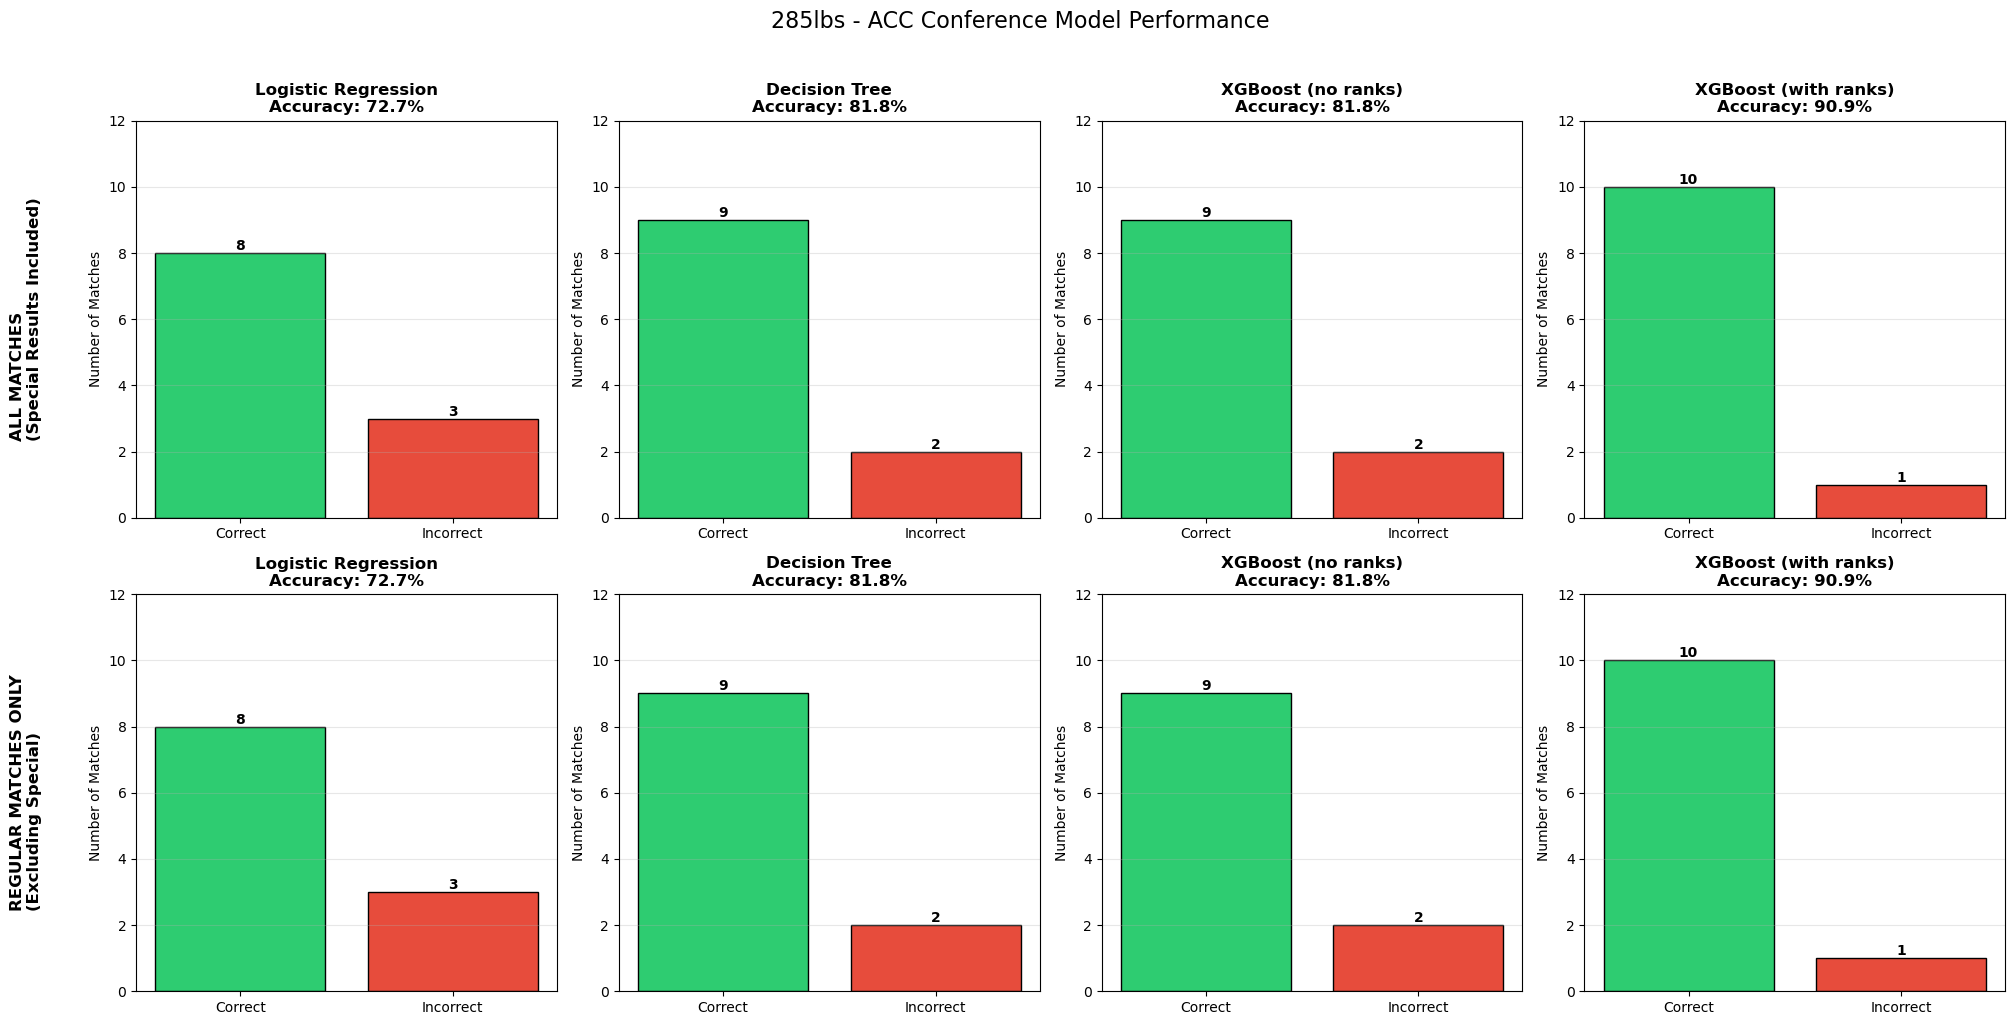


📊 MODEL RANKING - 285lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),90.9%,10/11
1,Decision Tree,81.8%,9/11
2,XGBoost (no ranks),81.8%,9/11
3,Logistic Regression,72.7%,8/11



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),90.9%,10/11
1,Decision Tree,81.8%,9/11
2,XGBoost (no ranks),81.8%,9/11
3,Logistic Regression,72.7%,8/11



📊 SUMMARY STATISTICS - 285lbs


,Metric,Value
0,Conference,ACC
1,Weight Class,285lbs
2,Total Matches Evaluated,11
3,Unique Matchups,11
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,11 (100.0%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),90.9%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 285lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,72.7%,8/11,72.7%,8/11
1,Decision Tree,81.8%,9/11,81.8%,9/11
2,XGBoost (no ranks),81.8%,9/11,81.8%,9/11
3,XGBoost (with ranks),90.9%,10/11,90.9%,10/11



✅ 285lbs evaluation complete and added to overall results

📊 285lbs Quick Results:
   Logistic Regression: 8/11 (72.7%)
   Decision Tree: 9/11 (81.8%)
   XGBoost (no ranks): 9/11 (81.8%)
   XGBoost (with ranks): 10/11 (90.9%)



In [13]:
# ============================================
# 285lbs ACTUAL RESULTS FROM ACC TOURNAMENT (WITH ROUNDS)
# ============================================

print("\n" + "="*100)
print("📋 SETTING UP 285lbs ACC TOURNAMENT RESULTS")
print("="*100)

# Using correct names from dataframe
# - Jimmy Mullen (might be "Jim Mullen" in your data)
# - Others should match

actual_results_285 = {
    # Quarterfinals
    ('Brenan Morgan', 'Connor Barket', 'Quarterfinal'): 'Brenan Morgan',  # MD 11-3
    ('Jimmy Mullen', 'Jacob Levy', 'Quarterfinal'): 'Jimmy Mullen',  # Fall 0:59
    ('Dayton Pitzer', 'Luke Duthie', 'Quarterfinal'): 'Dayton Pitzer',  # Fall 1:56
    # Note: Isaac Trumble had a bye - no match to record
    
    # Consolation Round 1
    ('Luke Duthie', 'Jacob Levy', 'Consolation Round 1'): 'Luke Duthie',  # Fall 5:58
    
    # Semifinals
    ('Isaac Trumble', 'Brenan Morgan', 'Semifinal'): 'Isaac Trumble',  # MD 13-2
    ('Dayton Pitzer', 'Jimmy Mullen', 'Semifinal'): 'Dayton Pitzer',  # MD 8-0
    
    # Consolation Semis
    ('Jimmy Mullen', 'Connor Barket', 'Consolation Semi'): 'Jimmy Mullen',  # MD 14-2
    ('Brenan Morgan', 'Luke Duthie', 'Consolation Semi'): 'Brenan Morgan',  # Fall 6:29
    
    # 3rd Place Match
    ('Jimmy Mullen', 'Brenan Morgan', '3rd Place Match'): 'Jimmy Mullen',  # TF-1.5 18-3
    
    # 5th Place Match
    ('Connor Barket', 'Luke Duthie', '5th Place Match'): 'Connor Barket',  # Dec 4-2
    
    # Championship Final
    ('Isaac Trumble', 'Dayton Pitzer', 'Championship'): 'Isaac Trumble',  # MD 9-0
}

# Track special matches (injury, forfeit, DQ) - none for 285lbs
special_matches_285 = []  # No special matches mentioned

print(f"\n📊 285lbs Results Summary:")
print(f"   Total matches: {len(actual_results_285)}")
print(f"   Special matches: {len(special_matches_285)}")

# Display actual matches
actual_matches_df_285 = []
for (w1, w2, round_name), winner in actual_results_285.items():
    is_special = (w1, w2, round_name) in special_matches_285 or (w2, w1, round_name) in special_matches_285
    actual_matches_df_285.append({
        'Round': round_name,
        'Wrestler 1': w1,
        'Wrestler 2': w2,
        'Winner': winner,
        'Type': 'SPECIAL' if is_special else 'REGULAR'
    })

# Sort by round order
round_order = ['Quarterfinal', 'Consolation Round 1', 'Semifinal', 'Consolation Semi', '3rd Place Match', '5th Place Match', 'Championship']
actual_matches_df_285 = pd.DataFrame(actual_matches_df_285)
actual_matches_df_285['Round Order'] = actual_matches_df_285['Round'].map({r: i for i, r in enumerate(round_order)})
actual_matches_df_285 = actual_matches_df_285.sort_values('Round Order').drop('Round Order', axis=1)
display(actual_matches_df_285)

# Verify all names exist in predictions
print("\n🔍 Verifying wrestler names in predictions dataset:")
wrestlers_285 = set()
for (w1, w2, _) in actual_results_285.keys():
    wrestlers_285.add(w1)
    wrestlers_285.add(w2)

preds_285 = acc_preds[acc_preds['weight_class'] == 285]
all_pred_wrestlers = set(preds_285['wrestler1'].tolist() + preds_285['wrestler2'].tolist())

# Common name variations to check
name_variations = {
    'Jimmy Mullen': ['Jimmy Mullen', 'Jim Mullen'],
}

missing_wrestlers = []
name_mapping = {}  # To track any needed renames

for wrestler in sorted(wrestlers_285):
    if wrestler in all_pred_wrestlers:
        print(f"✅ {wrestler} found in predictions")
    else:
        # Check for common variations
        found_variation = False
        if wrestler in name_variations:
            for variation in name_variations[wrestler]:
                if variation in all_pred_wrestlers:
                    print(f"⚠️ {wrestler} not found, but {variation} is available")
                    name_mapping[wrestler] = variation
                    found_variation = True
                    break
        
        if not found_variation:
            print(f"❌ {wrestler} NOT found in predictions")
            missing_wrestlers.append(wrestler)

if missing_wrestlers:
    print(f"\n⚠️ Missing wrestlers: {missing_wrestlers}")
    
    # Show available wrestlers in this weight class for reference
    print("\n📋 Available wrestlers in 285lbs predictions:")
    available = sorted(set(preds_285['wrestler1'].tolist() + preds_285['wrestler2'].tolist()))
    for w in available:
        print(f"   - {w}")
else:
    print("\n✅ All wrestlers found in predictions!")

# If we have name mappings, update the actual_results with correct names
if name_mapping:
    print("\n🔄 Updating results with correct names from predictions...")
    updated_results = {}
    for (w1, w2, round_name), winner in actual_results_285.items():
        new_w1 = name_mapping.get(w1, w1)
        new_w2 = name_mapping.get(w2, w2)
        new_winner = name_mapping.get(winner, winner)
        updated_results[(new_w1, new_w2, round_name)] = new_winner
    
    actual_results_285 = updated_results

# Check for multiple meetings
from collections import Counter
matchup_counter = Counter()
for (w1, w2, _) in actual_results_285.keys():
    matchup = tuple(sorted([w1, w2]))
    matchup_counter[matchup] += 1

multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
if multiple_meetings:
    print("\n⚠️ Multiple meetings detected:")
    for matchup in multiple_meetings:
        count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
        print(f"   {matchup}: {count} matches")
        
        # Show which rounds for multiple meetings
        print(f"      Rounds:")
        for (w1, w2, round_name), winner in actual_results_285.items():
            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                print(f"        - {round_name}: {winner} wins")
else:
    print("\n✅ No multiple meetings detected")

# Check for specific potential multiple meetings in 285lbs
print("\n🔍 Checking for potential multiple meetings:")
# Brenan Morgan vs Connor Barket - they meet in Quarterfinal only
# Jimmy Mullen vs Jacob Levy - they meet in Quarterfinal only
# Dayton Pitzer vs Luke Duthie - they meet in Quarterfinal only
# Jimmy Mullen vs Connor Barket - they meet in Consolation Semi only
# Brenan Morgan vs Luke Duthie - they meet in Consolation Semi only
# Jimmy Mullen vs Brenan Morgan - they meet in 3rd Place Match only
# Isaac Trumble vs Brenan Morgan - they meet in Semifinal only
# Dayton Pitzer vs Jimmy Mullen - they meet in Semifinal only
# Connor Barket vs Luke Duthie - they meet in 5th Place Match only
# Isaac Trumble vs Dayton Pitzer - they meet in Championship only
# No multiple meetings in this weight class

potential_multiples = [
    ('Brenan Morgan', 'Connor Barket'),
    ('Jimmy Mullen', 'Jacob Levy'),
    ('Dayton Pitzer', 'Luke Duthie'),
    ('Jimmy Mullen', 'Brenan Morgan'),
    ('Isaac Trumble', 'Dayton Pitzer'),
]

for w1, w2 in potential_multiples:
    # Use mapped names if available
    w1_mapped = name_mapping.get(w1, w1)
    w2_mapped = name_mapping.get(w2, w2)
    
    matches = [(r, win) for (a, b, r), win in actual_results_285.items() 
               if (a == w1_mapped and b == w2_mapped) or (a == w2_mapped and b == w1_mapped)]
    if len(matches) > 1:
        print(f"✅ Found: {w1_mapped} vs {w2_mapped} - {len(matches)} matches")
        for round_name, winner in matches:
            print(f"   - {round_name}: {winner} wins")
    elif len(matches) == 1:
        print(f"ℹ️ {w1_mapped} vs {w2_mapped} - {len(matches)} match ({matches[0][0]})")
    else:
        print(f"❌ {w1_mapped} vs {w2_mapped} - no matches")

# ============================================
# EVALUATE 285lbs
# ============================================

print("\n" + "="*100)
print("🔍 EVALUATING 285lbs")
print("="*100)

eval_285, summary_285 = evaluate_weight_class(
    weight_class=285,
    actual_results=actual_results_285,
    special_matches=special_matches_285,
    predictions_df=acc_preds,
    conference="ACC",
    save_plots=False
)

if summary_285:
    all_weight_results.append(summary_285)
    print("\n✅ 285lbs evaluation complete and added to overall results")
    
    # Quick summary of results
    print("\n📊 285lbs Quick Results:")
    if 'regular_metrics' in summary_285 and summary_285['regular_metrics']:
        for model, metrics in summary_285['regular_metrics'].items():
            print(f"   {model}: {metrics['correct']}/{metrics['total']} ({metrics['accuracy']:.1f}%)")
else:
    print("\n⚠️ 285lbs evaluation failed")

print("\n" + "="*100)

# Overall Statistics


🏆 CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Eddie Ventresca (Virginia Tech),Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Unanimous,✅
1,133 lbs,Aaron Seidel (Virginia Tech),Tyler Knox,Aaron Seidel,Aaron Seidel,Aaron Seidel,3/4 Models,❌
2,141 lbs,Jack Consiglio (Stanford),Gable Porter,Gable Porter,Ryan Jack,Ryan Jack,Split Decision,❌
3,149 lbs,Collin Gaj (Virginia Tech),Koy Buesgens,Koy Buesgens,Koy Buesgens,Koy Buesgens,Unanimous,❌
4,157 lbs,Daniel Cardenas (Stanford),Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Unanimous,✅
5,165 lbs,Bryce Hepner (North Carolina),Will Denny,Will Denny,Will Denny,Will Denny,Unanimous,❌
6,174 lbs,Matthew Singleton (NC State),Aiden Wallace,Matthew Singleton,Matthew Singleton,Matthew Singleton,3/4 Models,✅
7,184 lbs,Jaden Bullock (Virginia Tech),Jake Dailey,Jake Dailey,Jake Dailey,Jaden Bullock,3/4 Models,❌
8,197 lbs,Sonny Sasso (Virginia Tech),Sonny Sasso,Mac Stout,Sonny Sasso,Angelo Posada,Split Decision,✅
9,285 lbs,Isaac Trumble (NC State),Isaac Trumble,Isaac Trumble,Isaac Trumble,Isaac Trumble,Unanimous,✅



📊 MODEL CHAMPION PREDICTION ACCURACY


,Model,Correct Champions,Accuracy
0,LOGREG,4/10,40.0%
1,DT,5/10,50.0%
2,XGB1,6/10,60.0%
3,XGB2,6/10,60.0%



📊 Overall Champion Prediction Accuracy: 5/10 (50.0%)

📊 MATCH PREDICTION EVALUATION SUMMARY

📋 ALL MATCHES (Including Special Results):


...

,Model,Correct,Total,Accuracy
3,XGBoost (with ranks),81,107,75.7
2,XGBoost (no ranks),78,107,72.9
1,Logistic Regression,76,107,71.0
0,Decision Tree,74,107,69.2



🟢 REGULAR MATCHES ONLY (Excluding Special):


,Model,Correct,Total,Accuracy
3,XGBoost (with ranks),77,101,76.2
2,XGBoost (no ranks),74,101,73.3
1,Logistic Regression,72,101,71.3
0,Decision Tree,70,101,69.3



📊 MATCHES BY WEIGHT CLASS:


,Weight,Total Matches
0,125 lbs,11
1,133 lbs,10
2,141 lbs,11
3,149 lbs,11
4,157 lbs,11
5,165 lbs,11
6,174 lbs,10
7,184 lbs,11
8,197 lbs,10
9,285 lbs,11


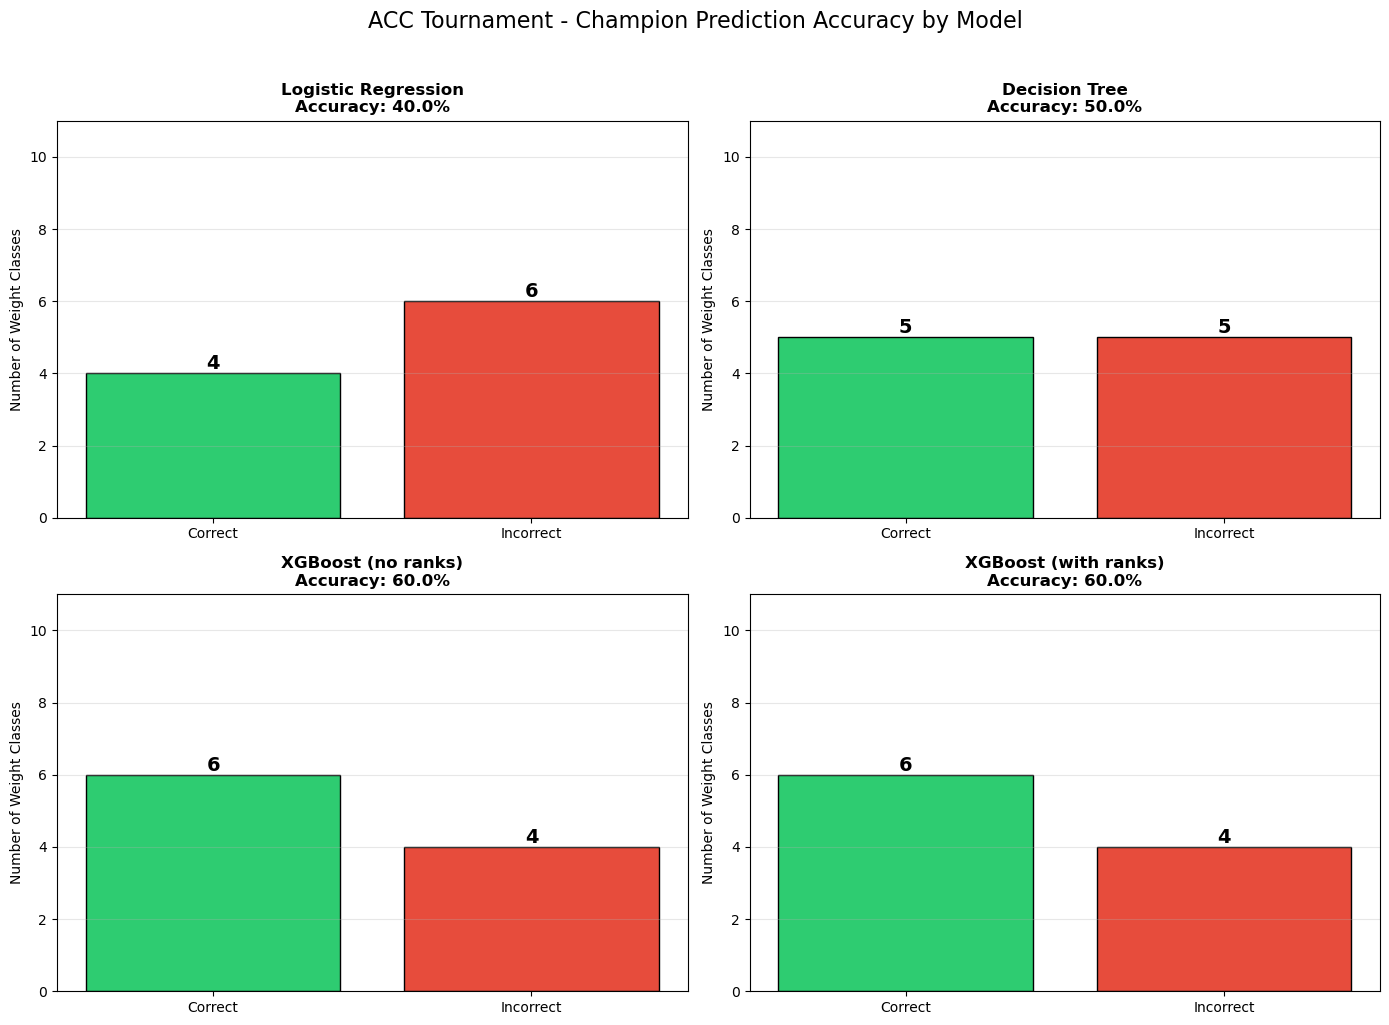

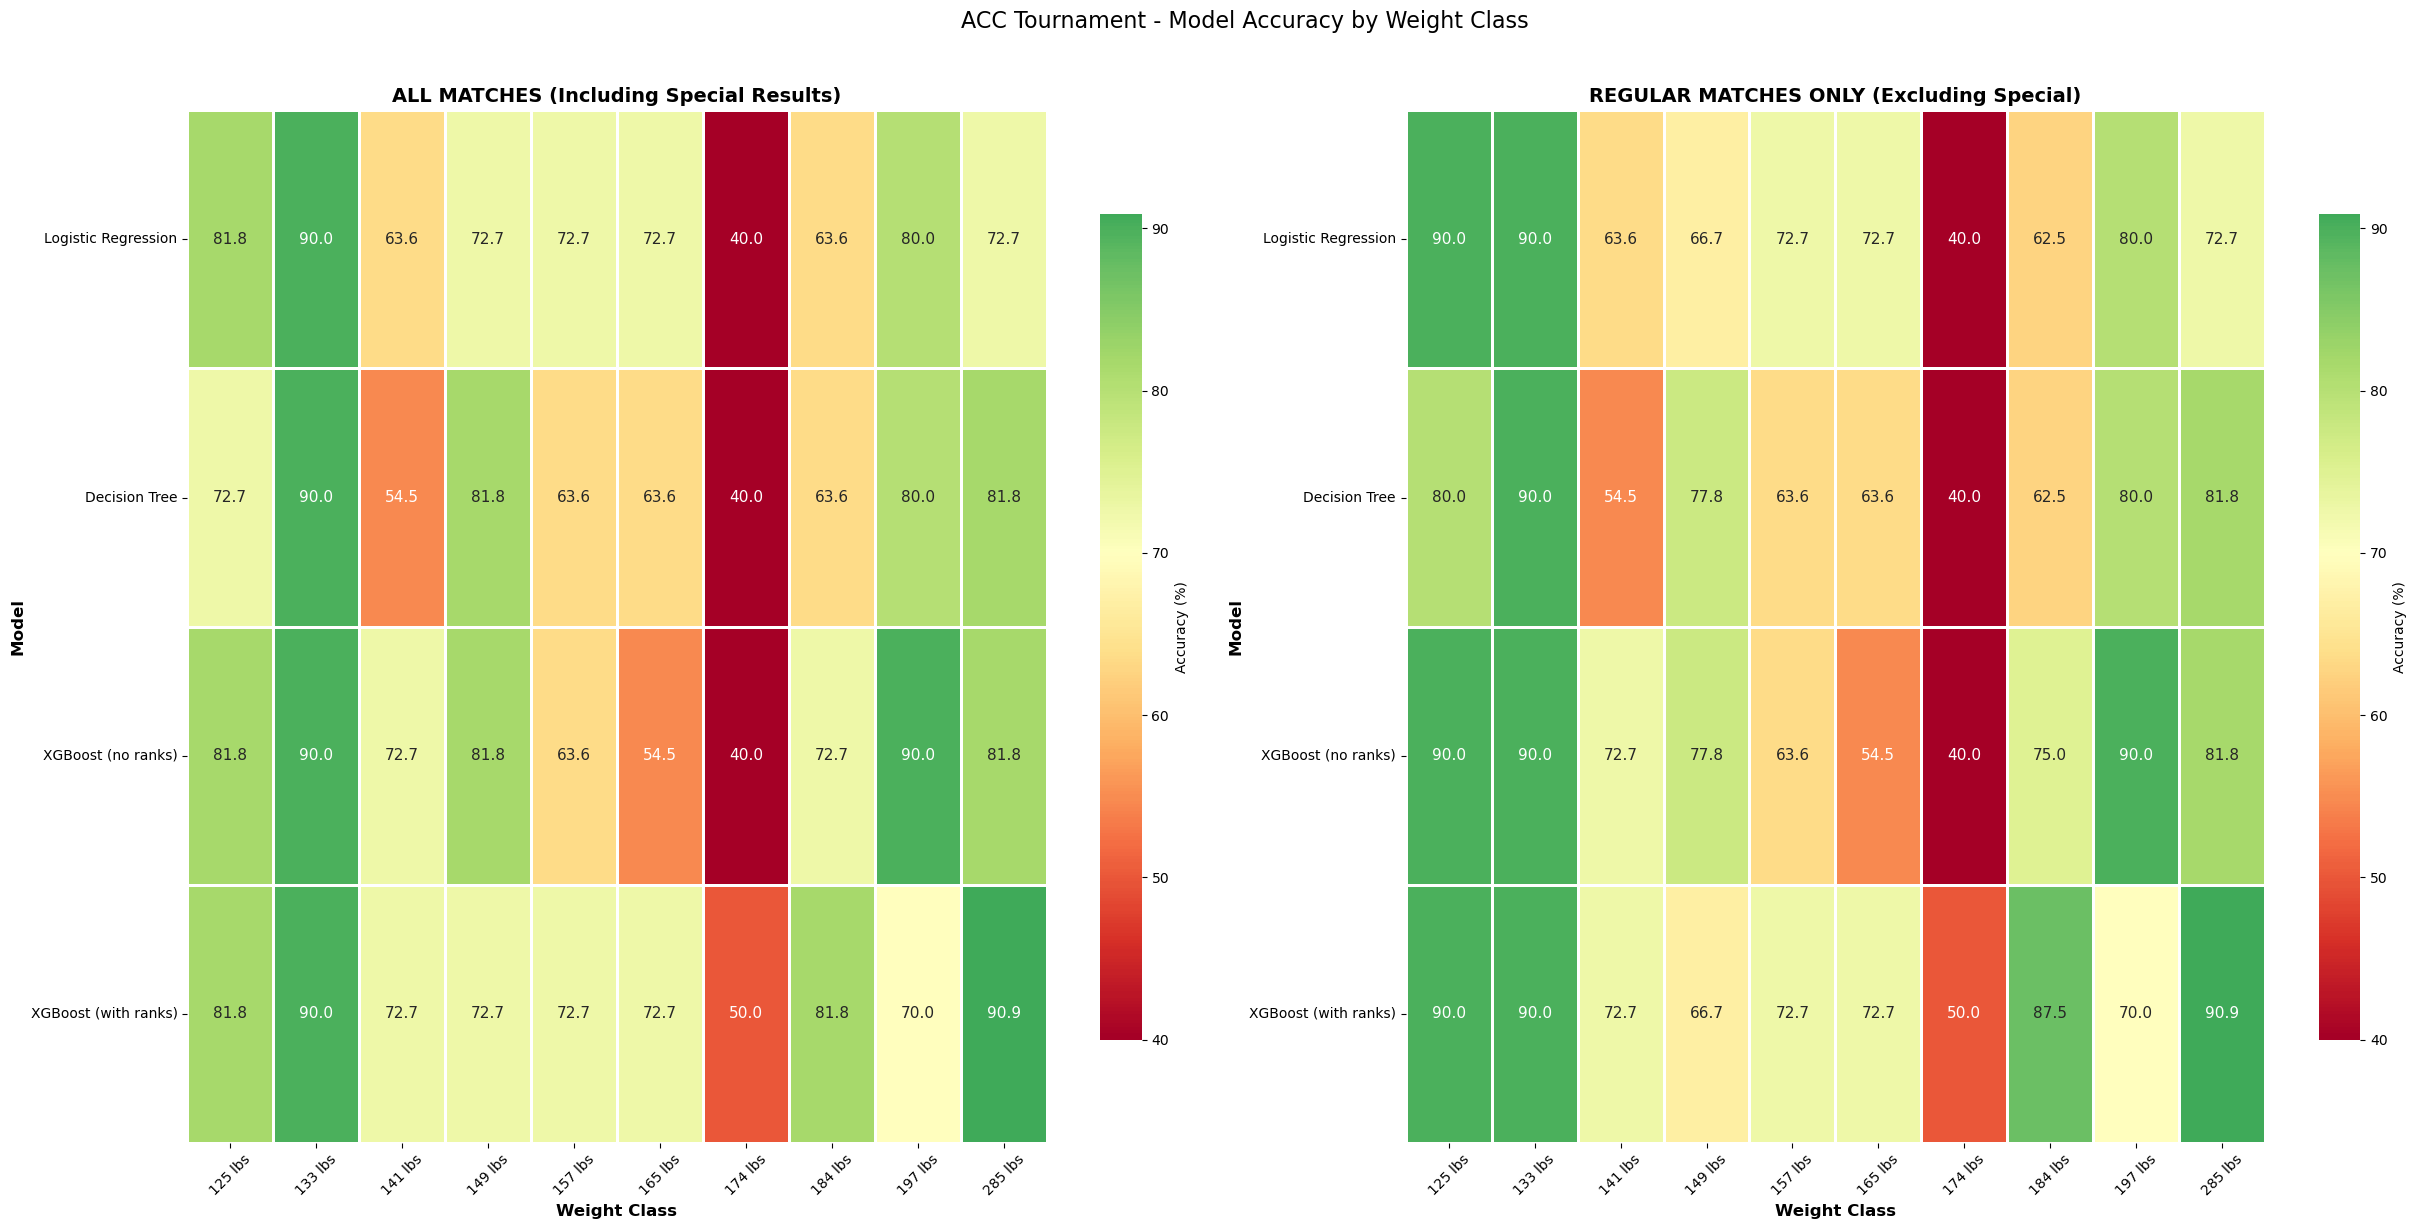


📊 SPECIAL MATCHES BY WEIGHT CLASS


,Weight,Total Matches,Special Matches,Regular Matches,Special %
0,125 lbs,11,1,10,9.1%
1,133 lbs,10,0,10,0.0%
2,141 lbs,11,0,11,0.0%
3,149 lbs,11,2,9,18.2%
4,157 lbs,11,0,11,0.0%
5,165 lbs,11,0,11,0.0%
6,174 lbs,10,0,10,0.0%
7,184 lbs,11,3,8,27.3%
8,197 lbs,10,0,10,0.0%
9,285 lbs,11,0,11,0.0%


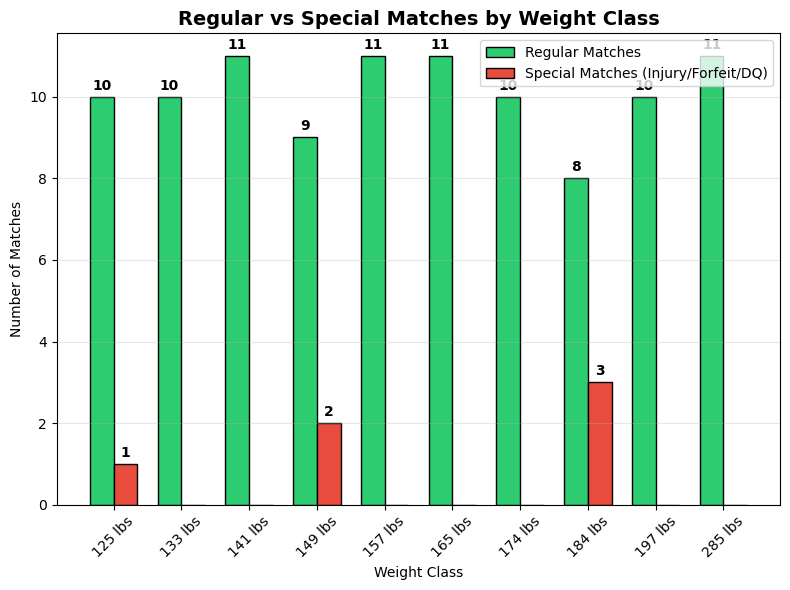


📋 COMPREHENSIVE ACC TOURNAMENT SUMMARY


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Eddie Ventresca (Virginia Tech),Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Unanimous,✅
1,133 lbs,Aaron Seidel (Virginia Tech),Tyler Knox,Aaron Seidel,Aaron Seidel,Aaron Seidel,3/4 Models,❌
2,141 lbs,Jack Consiglio (Stanford),Gable Porter,Gable Porter,Ryan Jack,Ryan Jack,Split Decision,❌
3,149 lbs,Collin Gaj (Virginia Tech),Koy Buesgens,Koy Buesgens,Koy Buesgens,Koy Buesgens,Unanimous,❌
4,157 lbs,Daniel Cardenas (Stanford),Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Unanimous,✅
5,165 lbs,Bryce Hepner (North Carolina),Will Denny,Will Denny,Will Denny,Will Denny,Unanimous,❌
6,174 lbs,Matthew Singleton (NC State),Aiden Wallace,Matthew Singleton,Matthew Singleton,Matthew Singleton,3/4 Models,✅
7,184 lbs,Jaden Bullock (Virginia Tech),Jake Dailey,Jake Dailey,Jake Dailey,Jaden Bullock,3/4 Models,❌
8,197 lbs,Sonny Sasso (Virginia Tech),Sonny Sasso,Mac Stout,Sonny Sasso,Angelo Posada,Split Decision,✅
9,285 lbs,Isaac Trumble (NC State),Isaac Trumble,Isaac Trumble,Isaac Trumble,Isaac Trumble,Unanimous,✅



✅ ALL ANALYSES COMPLETE - DATAFRAMES SAVED


In [19]:
# ============================================
# COMPLETE CHAMPION PREDICTION RESULTS (ALL 10 WEIGHTS)
# ============================================

# Actual champions from tournament results
actual_champions = {
    125: {'name': 'Eddie Ventresca', 'team': 'Virginia Tech'},
    133: {'name': 'Aaron Seidel', 'team': 'Virginia Tech'},
    141: {'name': 'Jack Consiglio', 'team': 'Stanford'},
    149: {'name': 'Collin Gaj', 'team': 'Virginia Tech'},
    157: {'name': 'Daniel Cardenas', 'team': 'Stanford'},
    165: {'name': 'Bryce Hepner', 'team': 'North Carolina'},
    174: {'name': 'Matthew Singleton', 'team': 'NC State'},
    184: {'name': 'Jaden Bullock', 'team': 'Virginia Tech'},
    197: {'name': 'Sonny Sasso', 'team': 'Virginia Tech'},
    285: {'name': 'Isaac Trumble', 'team': 'NC State'},
}

# Model predicted champions from your output
predicted_champions = {
    125: {
        'LOGREG': 'Eddie Ventresca',
        'DT': 'Eddie Ventresca',
        'XGB1': 'Eddie Ventresca',
        'XGB2': 'Eddie Ventresca',
        'consensus': 'Unanimous',
        'actual': 'Eddie Ventresca',
        'correct': True
    },
    133: {
        'LOGREG': 'Tyler Knox',
        'DT': 'Aaron Seidel',
        'XGB1': 'Aaron Seidel',
        'XGB2': 'Aaron Seidel',
        'consensus': '3/4 Models',
        'actual': 'Aaron Seidel',
        'correct': False
    },
    141: {
        'LOGREG': 'Gable Porter',
        'DT': 'Gable Porter',
        'XGB1': 'Ryan Jack',
        'XGB2': 'Ryan Jack',
        'consensus': 'Split Decision',
        'actual': 'Jack Consiglio',
        'correct': False
    },
    149: {
        'LOGREG': 'Koy Buesgens',
        'DT': 'Koy Buesgens',
        'XGB1': 'Koy Buesgens',
        'XGB2': 'Koy Buesgens',
        'consensus': 'Unanimous',
        'actual': 'Collin Gaj',
        'correct': False
    },
    157: {
        'LOGREG': 'Daniel Cardenas',
        'DT': 'Daniel Cardenas',
        'XGB1': 'Daniel Cardenas',
        'XGB2': 'Daniel Cardenas',
        'consensus': 'Unanimous',
        'actual': 'Daniel Cardenas',
        'correct': True
    },
    165: {
        'LOGREG': 'Will Denny',
        'DT': 'Will Denny',
        'XGB1': 'Will Denny',
        'XGB2': 'Will Denny',
        'consensus': 'Unanimous',
        'actual': 'Bryce Hepner',
        'correct': False
    },
    174: {
        'LOGREG': 'Aiden Wallace',
        'DT': 'Matthew Singleton',
        'XGB1': 'Matthew Singleton',
        'XGB2': 'Matthew Singleton',
        'consensus': '3/4 Models',
        'actual': 'Matthew Singleton',
        'correct': True
    },
    184: {
        'LOGREG': 'Jake Dailey',
        'DT': 'Jake Dailey',
        'XGB1': 'Jake Dailey',
        'XGB2': 'Jaden Bullock',
        'consensus': '3/4 Models',
        'actual': 'Jaden Bullock',
        'correct': False
    },
    197: {
        'LOGREG': 'Sonny Sasso',
        'DT': 'Mac Stout',
        'XGB1': 'Sonny Sasso',
        'XGB2': 'Angelo Posada',
        'consensus': 'Split Decision',
        'actual': 'Sonny Sasso',
        'correct': True
    },
    285: {
        'LOGREG': 'Isaac Trumble',
        'DT': 'Isaac Trumble',
        'XGB1': 'Isaac Trumble',
        'XGB2': 'Isaac Trumble',
        'consensus': 'Unanimous',
        'actual': 'Isaac Trumble',
        'correct': True
    },
}

# ============================================
# CREATE CHAMPION PREDICTION SUMMARY TABLE
# ============================================

champion_summary = []
weight_order = [125, 133, 141, 149, 157, 165, 174, 184, 197, 285]

for weight in weight_order:
    if weight in predicted_champions:
        p = predicted_champions[weight]
        actual = actual_champions[weight]
        
        # Determine model consensus display with emoji
        if p['consensus'] == 'Unanimous':
            consensus_display = '✅ Unanimous'
        elif p['consensus'] == '3/4 Models':
            consensus_display = '⚠️ 3/4 Models'
        else:
            consensus_display = '❌ Split Decision'
        
        champion_summary.append({
            'Weight': f'{weight} lbs',
            'Actual Champion': f"{actual['name']} ({actual['team']})",
            'LOGREG': p['LOGREG'],
            'DT': p['DT'],
            'XGB1': p['XGB1'],
            'XGB2': p['XGB2'],
            'Consensus': p['consensus'],
            'Correct': '✅' if p['correct'] else '❌'
        })

champion_df = pd.DataFrame(champion_summary)
print("\n🏆 CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS")
print("="*100)
display(champion_df)

# ============================================
# MODEL-BY-MODEL CHAMPION PREDICTION ACCURACY
# ============================================

model_accuracy = []
for model in ['LOGREG', 'DT', 'XGB1', 'XGB2']:
    correct = 0
    total = 0
    for weight in weight_order:
        if weight in predicted_champions:
            if predicted_champions[weight][model] == actual_champions[weight]['name']:
                correct += 1
            total += 1
    
    model_accuracy.append({
        'Model': model,
        'Correct Champions': f"{correct}/{total}",
        'Accuracy': f"{(correct/total*100):.1f}%"
    })

model_acc_df = pd.DataFrame(model_accuracy)
print("\n📊 MODEL CHAMPION PREDICTION ACCURACY")
print("="*100)
display(model_acc_df)

# ============================================
# OVERALL CHAMPION PREDICTION STATISTICS
# ============================================

total_correct = champion_df['Correct'].value_counts().get('✅', 0)
print(f"\n📊 Overall Champion Prediction Accuracy: {total_correct}/10 ({total_correct/10*100:.1f}%)")

# ============================================
# MATCH PREDICTION EVALUATION (from your evaluation data)
# ============================================

print("\n" + "="*100)
print("📊 MATCH PREDICTION EVALUATION SUMMARY")
print("="*100)

# This data comes from your all_weight_results list
# Let's compile it from the evaluations we did
if 'all_weight_results' in globals() and all_weight_results:
    
    # Compile all matches data
    all_matches_data = []
    regular_matches_data = []
    
    for result in all_weight_results:
        if result and 'all_metrics' in result and 'regular_metrics' in result:
            weight = result['weight_class']
            
            # All matches (including special)
            if result['all_metrics']:
                for model, metrics in result['all_metrics'].items():
                    all_matches_data.append({
                        'Weight': f"{weight} lbs",
                        'Model': model,
                        'Correct': metrics['correct'],
                        'Total': metrics['total'],
                        'Accuracy': metrics['accuracy']
                    })
            
            # Regular matches only (excluding special)
            if result['regular_metrics']:
                for model, metrics in result['regular_metrics'].items():
                    regular_matches_data.append({
                        'Weight': f"{weight} lbs",
                        'Model': model,
                        'Correct': metrics['correct'],
                        'Total': metrics['total'],
                        'Accuracy': metrics['accuracy']
                    })
    
    if all_matches_data:
        all_matches_df = pd.DataFrame(all_matches_data)
        regular_matches_df = pd.DataFrame(regular_matches_data)
        
        # Pivot tables for heatmap
        pivot_all = all_matches_df.pivot(index='Weight', columns='Model', values='Accuracy')
        pivot_regular = regular_matches_df.pivot(index='Weight', columns='Model', values='Accuracy')
        
        # Display summary tables
        print("\n📋 ALL MATCHES (Including Special Results):")
        display(all_matches_df.pivot_table(index='Weight', columns='Model', values='Accuracy', aggfunc='first').round(1))
        
        print("\n📋 REGULAR MATCHES ONLY (Excluding Special Results):")
        display(regular_matches_df.pivot_table(index='Weight', columns='Model', values='Accuracy', aggfunc='first').round(1))
        
        # Overall statistics
        print("\n📊 OVERALL MATCH PREDICTION STATISTICS:")
        
        # All matches overall
        all_overall = all_matches_df.groupby('Model').agg({
            'Correct': 'sum',
            'Total': 'sum'
        }).reset_index()
        all_overall['Accuracy'] = (all_overall['Correct'] / all_overall['Total'] * 100).round(1)
        all_overall = all_overall.sort_values('Accuracy', ascending=False)
        
        print("\n🔴 ALL MATCHES (Including Special):")
        display(all_overall[['Model', 'Correct', 'Total', 'Accuracy']])
        
        # Regular matches overall
        regular_overall = regular_matches_df.groupby('Model').agg({
            'Correct': 'sum',
            'Total': 'sum'
        }).reset_index()
        regular_overall['Accuracy'] = (regular_overall['Correct'] / regular_overall['Total'] * 100).round(1)
        regular_overall = regular_overall.sort_values('Accuracy', ascending=False)
        
        print("\n🟢 REGULAR MATCHES ONLY (Excluding Special):")
        display(regular_overall[['Model', 'Correct', 'Total', 'Accuracy']])
        
        # Weight class summary
        print("\n📊 MATCHES BY WEIGHT CLASS:")
        weight_summary = all_matches_df.groupby('Weight').agg({
            'Total': 'first'
        }).reset_index()
        weight_summary.columns = ['Weight', 'Total Matches']
        display(weight_summary)

# ============================================
# CREATE HEATMAP VISUALIZATIONS
# ============================================

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Figure 1: Champion Prediction Accuracy by Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = ['LOGREG', 'DT', 'XGB1', 'XGB2']
model_names = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']

for idx, (model, name) in enumerate(zip(models, model_names)):
    # Count correct/incorrect champion predictions
    correct = sum(1 for w in weight_order if w in predicted_champions and 
                  predicted_champions[w][model] == actual_champions[w]['name'])
    incorrect = 10 - correct
    
    bars = axes[idx].bar(['Correct', 'Incorrect'], [correct, incorrect], 
                         color=['#2ecc71', '#e74c3c'], edgecolor='black')
    
    # Add labels
    for bar, count in zip(bars, [correct, incorrect]):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=14)
    
    axes[idx].set_title(f'{name}\nAccuracy: {correct/10*100:.1f}%', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Number of Weight Classes')
    axes[idx].set_ylim(0, 11)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('ACC Tournament - Champion Prediction Accuracy by Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Figure 2: Heatmap of All Matches Accuracy by Weight Class (HORIZONTAL ORIENTATION)
if 'all_matches_df' in locals() and not all_matches_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(25, 12))
    
    # Heatmap for All Matches - Horizontal orientation (models on y-axis, weights on x-axis)
    pivot_all = all_matches_df.pivot(index='Model', columns='Weight', values='Accuracy')
    
    # Reorder models for better comparison
    model_order = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']
    pivot_all = pivot_all.reindex(model_order)
    
    sns.heatmap(pivot_all, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
                linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8}, 
                annot_kws={'size': 11}, ax=axes[0])
    axes[0].set_title('ALL MATCHES (Including Special Results)', fontweight='bold', fontsize=14)
    axes[0].set_ylabel('Model', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # Heatmap for Regular Matches Only - Horizontal orientation
    if not regular_matches_df.empty:
        pivot_regular = regular_matches_df.pivot(index='Model', columns='Weight', values='Accuracy')
        pivot_regular = pivot_regular.reindex(model_order)
        
        sns.heatmap(pivot_regular, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
                    linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
                    annot_kws={'size': 11}, ax=axes[1])
        axes[1].set_title('REGULAR MATCHES ONLY (Excluding Special)', fontweight='bold', fontsize=14)
        axes[1].set_ylabel('Model', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='y', rotation=0)
    
    plt.suptitle('ACC Tournament - Model Accuracy by Weight Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Figure 3: Special Matches Analysis
if 'all_weight_results' in globals() and all_weight_results:
    special_data = []
    for result in all_weight_results:
        if result:
            special_data.append({
                'Weight': f"{result['weight_class']} lbs",
                'Total Matches': result['total_matches'],
                'Special Matches': result['special_matches'],
                'Regular Matches': result['regular_matches'],
                'Special %': f"{(result['special_matches']/result['total_matches']*100):.1f}%" if result['total_matches'] > 0 else '0%'
            })
    
    if special_data:
        special_df = pd.DataFrame(special_data)
        print("\n📊 SPECIAL MATCHES BY WEIGHT CLASS")
        print("="*100)
        display(special_df)
        
        # Bar chart of special matches
        fig, ax = plt.subplots(figsize=(8, 6))
        x = range(len(special_df))
        width = 0.35
        
        ax.bar([i - width/2 for i in x], special_df['Regular Matches'], width, 
               label='Regular Matches', color='#2ecc71', edgecolor='black')
        ax.bar([i + width/2 for i in x], special_df['Special Matches'], width, 
               label='Special Matches (Injury/Forfeit/DQ)', color='#e74c3c', edgecolor='black')
        
        ax.set_xlabel('Weight Class')
        ax.set_ylabel('Number of Matches')
        ax.set_title('Regular vs Special Matches by Weight Class', fontweight='bold', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(special_df['Weight'], rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, row in special_df.iterrows():
            ax.text(i - width/2, row['Regular Matches'] + 0.1, str(row['Regular Matches']), 
                   ha='center', va='bottom', fontweight='bold')
            if row['Special Matches'] > 0:
                ax.text(i + width/2, row['Special Matches'] + 0.1, str(row['Special Matches']), 
                       ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

# ============================================
# COMPREHENSIVE SUMMARY TABLE
# ============================================

print("\n" + "="*100)
print("📋 COMPREHENSIVE ACC TOURNAMENT SUMMARY")
print("="*100)

# Display the champion dataframe
display(champion_df)

# ============================================
# SAVE ALL DATAFRAMES TO CSV
# ============================================

# print("\n💾 SAVING DATAFRAMES TO CSV...")

# # Save champion predictions
# champion_df.to_csv('ACC_champion_predictions.csv', index=False)
# print("   ✅ Saved: ACC_champion_predictions.csv")

# # Save model accuracy
# model_acc_df.to_csv('ACC_model_champion_accuracy.csv', index=False)
# print("   ✅ Saved: ACC_model_champion_accuracy.csv")

# # Save match accuracy if available
# if 'all_matches_df' in locals() and not all_matches_df.empty:
#     all_matches_df.to_csv('ACC_all_matches_accuracy.csv', index=False)
#     print("   ✅ Saved: ACC_all_matches_accuracy.csv")
    
#     if not regular_matches_df.empty:
#         regular_matches_df.to_csv('ACC_regular_matches_accuracy.csv', index=False)
#         print("   ✅ Saved: ACC_regular_matches_accuracy.csv")

# # Save special matches data
# if 'special_df' in locals() and not special_df.empty:
#     special_df.to_csv('ACC_special_matches_summary.csv', index=False)
#     print("   ✅ Saved: ACC_special_matches_summary.csv")

print("\n" + "="*100)
print("✅ ALL ANALYSES COMPLETE - DATAFRAMES SAVED")
print("="*100)